**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu | +1 (305) 409-3108  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)  

# Non-Linear Economy Estimation (ANN)

## Reproducibility and runtime

All computations are executed in a Python virtual environment targeting Python 3.13. As in the linear environment notebook, results may differ across Python or package versions due to numerical and API-level changes. For replication, the full dependency set should therefore be recorded alongside notebook outputs, for example using pip freeze. This is particularly important here because the nonlinear environment is sensitive to numerical precision, initialization, and optimizer behavior.

## Software and libraries

The nonlinear environment uses the same core data and plotting stack as the linear environment, while replacing the linear econometric estimation layer with a PyTorch-native neural-network implementation. The current notebook already imports torch, torch.nn, and the standard Python modules needed for custom model classes and training utilities. The linear notebook’s software stack also provides the data pipeline, plotting, and reproducibility infrastructure on which the nonlinear environment builds.

- **Python** (>= 3.13)
- **PyTorch** — neural-network modeling, tensor computation, and custom optimization routines
- **pandas** — data wrangling and time-series preparation
- **numpy** — numerical computing
- **matplotlib** — figures and visualization
- **fedfred** — programmatic access to FRED data
- **Jupyter / IPython** — interactive execution and display utilities

This combination mirrors the linear notebook’s reproducible research workflow while extending it to nonlinear function approximation.

In [1]:
%pip install torch fedfred pandas numpy matplotlib ipympl ipywidgets jupyterlab-lsp nbdime --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib widget

In [3]:
from dataclasses import dataclass
from typing import List, Optional, Sequence, Tuple, Dict
import copy
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import fedfred as fed

---------

# Baseline Specification (Bundesbank-aligned NARX)

## Motivation and relation to the linear benchmark

The nonlinear environment is designed as the ANN analogue of the restricted linear benchmark. In the linear notebook, the baseline recursive SVAR(2) is first estimated in full and then restricted by dropping statistically weak second-lag terms. The resulting restricted system is then used as the compact benchmark environment.

Accordingly, the nonlinear environment should preserve that same reduced information structure so that the linear and nonlinear environments remain directly comparable.

## Corrected nonlinear transition equations

Let $y_t$ denote the output gap, $\pi_t$ inflation, and $i_t$ the policy rate. After applying the lag restrictions from the linear environment, the nonlinear economy is written as follows.

### Output-gap equation

The output-gap network uses only first-lag regressors:

$$
y_t = \hat f_y\!\left(y_{t-1}, \pi_{t-1}, i_{t-1}\right) + \varepsilon_t^y
$$

This matches the restricted linear output-gap equation, where the retained nonzero terms are the constant, $y_{t-1}$, $\pi_{t-1}$, and $i_{t-1}$, while $y_{t-2}$, $\pi_{t-2}$, and $i_{t-2}$ are dropped.

### Inflation equation

The inflation network retains contemporaneous output and the restricted lag structure:

$$
\pi_t = \hat f_\pi\!\left(y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}\right) + \varepsilon_t^\pi
$$

This matches the restricted linear inflation equation, where $i_{t-2}$ is dropped but $y_t$, $y_{t-1}$, $y_{t-2}$, $\pi_{t-1}$, $\pi_{t-2}$, and $i_{t-1}$ remain.

### Conditional interpretation

Because the inflation equation includes contemporaneous $y_t$, the inflation network is recursive or triangular in the same sense as the linear notebook’s inflation equation. Therefore:

- conditional one-step inflation predictions should use realized $y_t$
- fully recursive simulation would instead substitute $\hat y_t$

This distinction should remain explicit throughout the nonlinear notebook.

## Data source, sample, and observables

The nonlinear environment uses the same quarterly macroeconomic panel as the linear benchmark so that nonlinear and linear results remain directly comparable. The sample definition, variable construction, and frequency treatment are therefore unchanged relative to the restricted linear environment.

### Sample window

The estimation sample is 1987Q3–2007Q2. This is the same pre-crisis training window used in the linear notebook and is retained here so that the nonlinear environment is estimated on the exact same historical information set.

### Frequency

All series are used at quarterly frequency. When the underlying raw series are available at higher frequency, they are aggregated to quarters before model construction.

### Observables

We use the same three observables as in the linear benchmark:

- inflation, $\pi_t$: year-over-year percent change in the GDP implicit price deflator
- output gap, $y_t$: percent deviation of real GDP from potential GDP
- policy rate, $i_t$: quarterly average of the effective federal funds rate

This ensures that any performance difference between the linear and nonlinear environments is attributable to the functional form and estimation procedure rather than to a different data construction pipeline.

### Variable definitions

Inflation is defined as

$$
\pi_t = 100\left(\frac{P_t}{P_{t-4}} - 1\right),
$$

where $P_t$ is the GDP implicit price deflator.

The output gap is defined as

$$
y_t = 100\left(\frac{Y_t}{Y_t^*} - 1\right),
$$

where $Y_t$ is real GDP and $Y_t^*$ is potential GDP.

The policy indicator $i_t$ is the effective federal funds rate aggregated to the quarterly frequency by averaging within quarter.

### Data replication from the linear notebook

Because the nonlinear notebook is built as the ANN counterpart to the linear environment, it replicates the same merged quarterly dataset from the linear notebook. Even so, the data are rechecked here so that the nonlinear notebook remains self-contained and fully auditable on its own.

In [4]:
# Training data Time Period: Q3 1987 - Q2 2007
start_date = "1987-07-01"
end_date = "2007-06-30"

# Training data Observation Frequency
freq = "q"  # Quarterly

# Fred client
fred = fed.FredAPI(api_key="7ab121fb17773e187bb6508e83e411da", cache_mode=True, cache_size=256)

# Fetch data from FRED
gdpdef_yoy = fred.get_series_observations(
    series_id="GDPDEF",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="pc1" # YoY percent change
)

real_gdp = fred.get_series_observations(
    series_id="GDPC1",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="lin" # Linear units (level)
)

potential_gdp = fred.get_series_observations(
    series_id="GDPPOT",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="lin" # Linear units (level)
)

effective_ffr = fred.get_series_observations(
    series_id="FEDFUNDS",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    aggregation_method="avg" # Aggregate daily data to quarterly by averaging (specificly important for interest rates)
)

# Convert to Series with proper names
pi = fed.FredHelpers.to_pd_series(gdpdef_yoy, "pi")
y_real = fed.FredHelpers.to_pd_series(real_gdp, "y_real")
y_pot = fed.FredHelpers.to_pd_series(potential_gdp, "y_pot")
i = fed.FredHelpers.to_pd_series(effective_ffr, "i")

y_gap = 100.0 * (y_real / y_pot - 1.0)
y_gap.name = "y"

# Merge
df = pd.concat([pi, y_gap, i], axis=1).dropna()
df.index = pd.PeriodIndex(df.index, freq="Q") # Use a quarterly PeriodIndex

# Check
print(df.head())
print(df.tail())
print(df.index.min(), "→", df.index.max())

# Additional Sanity Check:
assert df.index.min() == pd.Period("1987Q3", "Q")
assert df.index.max() == pd.Period("2007Q2", "Q")
assert len(df) == 80
assert not df.isna().any().any()

df_train = df.copy()

             pi         y     i
date                           
1987Q3  2.66122 -0.320752  6.84
1987Q4  2.91876  0.612983  6.92
1988Q1  3.06577  0.370773  6.66
1988Q2  3.35274  0.932239  7.16
1988Q3  3.80207  0.779457  7.98
             pi         y     i
date                           
2006Q2  3.35642  1.316103  4.91
2006Q3  3.13805  0.921755  5.25
2006Q4  2.66316  1.268135  5.25
2007Q1  2.91019  1.053059  5.26
2007Q2  2.72883  1.151432  5.25
1987Q3 → 2007Q2


In [5]:
# Confirm that the training data matches the linear notebook
required_columns = {"pi", "y", "i"}

if "df_train" not in globals():
    raise RuntimeError(
        "df_train was not found. Ensure the linear environment notebook has been run "
        "or that the training dataframe has been defined before continuing."
    )

missing_columns = required_columns.difference(df_train.columns)
if missing_columns:
    raise ValueError(
        f"df_train is missing required columns: {sorted(missing_columns)}"
    )

print("df_train found.")
print("Columns:", list(df_train.columns))
print("Index type:", type(df_train.index).__name__)

df_train found.
Columns: ['pi', 'y', 'i']
Index type: PeriodIndex


## Data integrity checks

Before constructing nonlinear design matrices, the training sample is checked for:

- correct quarterly indexing,
- correct sample bounds,
- absence of missing values,
- numeric finiteness of all observables,
- reasonable descriptive ranges.

These checks help ensure that any later training instability reflects model behavior rather than silent data corruption or index misalignment.

In [6]:
df_nl = df_train.loc[:, ["pi", "y", "i"]].copy().sort_index()

# Basic structural checks
assert isinstance(df_nl.index, pd.PeriodIndex), "Expected a quarterly PeriodIndex."
assert str(df_nl.index.freqstr).upper().startswith("Q"), "Expected quarterly PeriodIndex frequency."
assert df_nl.index.min() == pd.Period("1987Q3", freq="Q"), "Unexpected start date."
assert df_nl.index.max() == pd.Period("2007Q2", freq="Q"), "Unexpected end date."
assert len(df_nl) == 80, "Unexpected number of training observations."

# Missingness and finiteness checks
assert not df_nl.isna().any().any(), "Training data contain missing values."
assert np.isfinite(df_nl.to_numpy(dtype=float)).all(), "Training data contain non-finite values."

print("All structural and integrity checks passed.")

All structural and integrity checks passed.


In [7]:
print(df_nl.head(), "\n")
print(df_nl.tail(), "\n")
print("Sample span:", df_nl.index.min(), "→", df_nl.index.max())
print("Number of observations:", len(df_nl))

             pi         y     i
date                           
1987Q3  2.66122 -0.320752  6.84
1987Q4  2.91876  0.612983  6.92
1988Q1  3.06577  0.370773  6.66
1988Q2  3.35274  0.932239  7.16
1988Q3  3.80207  0.779457  7.98 

             pi         y     i
date                           
2006Q2  3.35642  1.316103  4.91
2006Q3  3.13805  0.921755  5.25
2006Q4  2.66316  1.268135  5.25
2007Q1  2.91019  1.053059  5.26
2007Q2  2.72883  1.151432  5.25 

Sample span: 1987Q3 → 2007Q2
Number of observations: 80


### Descriptive summary

The following summary table provides a compact check on location, dispersion, and support for the three observables over the nonlinear training sample.

In [8]:
summary_stats = df_nl.describe().T.loc[:, ["mean", "std", "min", "25%", "50%", "75%", "max"]]
summary_stats

,mean,std,min,25%,50%,75%,max
pi,2.465956,0.800033,1.087600,1.913298,2.334620,3.080278,4.233260
y,0.191801,1.266773,-2.242576,-0.815819,0.416508,1.256752,2.481939
i,4.837250,2.171574,1.000000,3.172500,5.250000,5.822500,9.730000


In [9]:
print("Additional range checks:")
for col in ["pi", "y", "i"]:
    series = df_nl[col]
    print(
        f"{col}: "
        f"min={series.min():.4f}, "
        f"max={series.max():.4f}, "
        f"mean={series.mean():.4f}, "
        f"std={series.std():.4f}"
    )

Additional range checks:
pi: min=1.0876, max=4.2333, mean=2.4660, std=0.8000
y: min=-2.2426, max=2.4819, mean=0.1918, std=1.2668
i: min=1.0000, max=9.7300, mean=4.8373, std=2.1716


## NARX architecture

The nonlinear transition equations are approximated using shallow feedforward neural networks in a NARX (Nonlinear AutoRegressive with eXogenous inputs) framework. NARX models are a standard approach for modeling nonlinear dynamic systems with lagged endogenous and exogenous inputs (Chen & Billings, 1992; Narendra & Parthasarathy, 1990).

For each equation $m \in \{y,\pi\}$, define

$$
\hat f_m(s_t^m)
=
b_{0}^{m}
+
\sum_{j=1}^{h_m}
v_j^{m}\,
G\!\left((w_j^{m})' s_t^m + b_j^{m}\right),
$$

where:

- $s_t^y = (y_{t-1}, \pi_{t-1}, i_{t-1})$
- $s_t^\pi = (y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1})$
- $h_m$ is the number of hidden neurons in equation $m$
- $w_j^m$ is the hidden-layer weight vector
- $b_j^m$ is the hidden-layer bias
- $v_j^m$ is the output-layer weight
- $b_0^m$ is the output-layer bias

The activation function is the hyperbolic tangent:

$$
G(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}.
$$

The tanh activation is commonly used in shallow networks due to its smoothness and favorable optimization properties relative to piecewise-linear alternatives in small-sample settings (LeCun et al., 2012). The network is intentionally kept shallow so that it remains comparable to the linear benchmark and so that Levenberg–Marquardt estimation remains computationally feasible.

## Numerical implementation choices

### Float64 and CPU execution

To better replicate the numerical behavior of the reference MATLAB implementation, tensors are evaluated in double precision (`torch.float64`). On the local ARM64 MacBook Pro environment, this implies CPU-based training rather than MPS acceleration because MPS does not support float64. This tradeoff favors numerical fidelity over raw speed and is appropriate for the small-network, replication-oriented setting considered here.

In [10]:
DTYPE = torch.float64
DEVICE = torch.device("cpu")

### Determinism

For reproducibility, deterministic PyTorch algorithms are enabled so that repeated runs under the same seed and software environment produce stable results whenever possible. This is particularly important because initialization and nonlinear optimization materially affect ANN estimates.

In [11]:
torch.use_deterministic_algorithms(True)

## Utility helpers

Before constructing the nonlinear model, the notebook defines a small set of internal helper functions to standardize tensor handling. These helpers enforce two-dimensional input shapes, check for non-finite values, flatten parameter collections into a single vector, and reassign flat parameter vectors back into model weights. This machinery is necessary because the Levenberg–Marquardt optimizer operates directly on vectorized parameters and Jacobian matrices rather than using PyTorch’s standard first-order optimizer interface.

In [12]:
def _to_2d_tensor(x: torch.Tensor) -> torch.Tensor:
    """Ensure tensor is 2D."""
    if not isinstance(x, torch.Tensor):
        raise TypeError(f"Expected torch.Tensor, got {type(x).__name__}.")
    if x.ndim == 1:
        return x.unsqueeze(1)
    if x.ndim != 2:
        raise ValueError(f"Expected 1D or 2D tensor, got shape {tuple(x.shape)}.")
    return x


def _validate_finite_tensor(x: torch.Tensor, name: str) -> None:
    """Validate that a tensor contains only finite values."""
    if not torch.isfinite(x).all():
        raise ValueError(f"Tensor '{name}' contains NaN or infinite values.")


def _flatten_parameters(parameters: Sequence[torch.nn.Parameter]) -> torch.Tensor:
    """Flatten a sequence of parameters into a single 1D tensor."""
    flat_parts: List[torch.Tensor] = []
    for parameter in parameters:
        flat_parts.append(parameter.detach().reshape(-1))
    if not flat_parts:
        raise ValueError("No parameters were provided for flattening.")
    return torch.cat(flat_parts)


def _assign_flat_parameters(parameters: Sequence[torch.nn.Parameter], flat_vector: torch.Tensor) -> None:
    """Assign a flat parameter vector back into model parameters in-place."""
    if flat_vector.ndim != 1:
        raise ValueError("Flat parameter vector must be 1D.")

    offset = 0
    with torch.no_grad():
        for parameter in parameters:
            numel = parameter.numel()
            parameter.copy_(flat_vector[offset:offset + numel].view_as(parameter))
            offset += numel

    if offset != flat_vector.numel():
        raise ValueError(
            "Flat parameter vector size does not match total model parameter size."
        )


def _num_parameters(parameters: Sequence[torch.nn.Parameter]) -> int:
    """Return total number of scalar parameters."""
    return sum(parameter.numel() for parameter in parameters)

## Input scaling: PyTorch-native `mapminmax`

The nonlinear environment uses a PyTorch-native implementation of MATLAB’s `mapminmax` transformation. Each feature is scaled independently from its observed sample range to a user-specified target interval, with default range $[-1,1]$. For `tanh` networks, this is the natural normalization because it places the regressors in the region where the activation function remains most responsive. Constant columns are handled separately so that division-by-zero issues are avoided and their transformed values remain well-defined.

For feature $x_j$, the transformation is

$$
x_{j,\mathrm{scaled}}
=
a
+
\frac{x_j - x_j^{\min}}{x_j^{\max} - x_j^{\min}}
(b-a),
$$

where $[a,b]$ is the target interval, here typically $[-1,1]$.

Because the two equations use different regressor sets, the nonlinear environment should later fit separate input and target scalers for each equation.

In [13]:
class MapMinMaxScaler:
    """
    PyTorch-native analogue of MATLAB's mapminmax.

    Transforms each feature independently from observed data range
    [x_min, x_max] into [feature_range[0], feature_range[1]].

    Default output range is [-1, 1], which is appropriate for tanh networks.
    """

    def __init__(self, feature_range: Tuple[float, float] = (-1.0, 1.0), eps: float = 1e-12) -> None:
        """
        Args:
            feature_range: Desired output range.
            eps: Small constant to avoid division by zero.
        """
        lower, upper = feature_range
        if lower >= upper:
            raise ValueError("feature_range must satisfy lower < upper.")
        if eps <= 0:
            raise ValueError("eps must be strictly positive.")

        self.feature_range = feature_range
        self.eps = float(eps)

        self.data_min_: Optional[torch.Tensor] = None
        self.data_max_: Optional[torch.Tensor] = None
        self.data_range_: Optional[torch.Tensor] = None
        self.scale_: Optional[torch.Tensor] = None
        self.min_: Optional[torch.Tensor] = None
        self.n_features_in_: Optional[int] = None
        self.fitted_: bool = False

    def fit(self, x: torch.Tensor) -> "MapMinMaxScaler":
        """
        Fit the scaler on 2D data of shape (n_samples, n_features).
        """
        x = _to_2d_tensor(x)
        _validate_finite_tensor(x, "x")

        self.data_min_ = x.min(dim=0).values
        self.data_max_ = x.max(dim=0).values
        self.data_range_ = self.data_max_ - self.data_min_

        lower, upper = self.feature_range
        safe_range = torch.where(
            self.data_range_ < self.eps,
            torch.ones_like(self.data_range_),
            self.data_range_
        )

        self.scale_ = (upper - lower) / safe_range
        self.min_ = lower - self.data_min_ * self.scale_
        self.n_features_in_ = x.shape[1]
        self.fitted_ = True

        return self

    def transform(self, x: torch.Tensor) -> torch.Tensor:
        """
        Transform data using fitted scaling parameters.
        """
        if not self.fitted_:
            raise RuntimeError("Scaler must be fitted before calling transform().")

        x = _to_2d_tensor(x)
        _validate_finite_tensor(x, "x")

        if x.shape[1] != self.n_features_in_:
            raise ValueError(
                f"Expected {self.n_features_in_} features, got {x.shape[1]}."
            )

        transformed = x * self.scale_ + self.min_

        lower, upper = self.feature_range
        midpoint = (lower + upper) / 2.0
        constant_mask = self.data_range_ < self.eps
        if constant_mask.any():
            transformed[:, constant_mask] = midpoint

        return transformed

    def inverse_transform(self, x_scaled: torch.Tensor) -> torch.Tensor:
        """
        Invert scaling back to original units.
        """
        if not self.fitted_:
            raise RuntimeError("Scaler must be fitted before inverse_transform().")

        x_scaled = _to_2d_tensor(x_scaled)
        _validate_finite_tensor(x_scaled, "x_scaled")

        if x_scaled.shape[1] != self.n_features_in_:
            raise ValueError(
                f"Expected {self.n_features_in_} features, got {x_scaled.shape[1]}."
            )

        original = (x_scaled - self.min_) / self.scale_

        constant_mask = self.data_range_ < self.eps
        if constant_mask.any():
            original[:, constant_mask] = self.data_min_[constant_mask]

        return original

    def fit_transform(self, x: torch.Tensor) -> torch.Tensor:
        """
        Fit and transform in one step.
        """
        return self.fit(x).transform(x)

## Nguyen–Widrow initialization

To replicate the reference neural-network setup more closely, hidden-layer parameters are initialized using the Nguyen–Widrow method (Nguyen & Widrow, 1990). This initialization is designed for shallow feedforward networks with bounded nonlinear activations such as `tanh`. Its purpose is to distribute hidden neurons across the informative region of the activation function at the start of training, reducing the risk that many neurons begin in heavily saturated regions where local sensitivity is weak.

Let $w_i^0$ be the preliminary weight vector for hidden unit $i$, drawn from a uniform distribution. Nguyen–Widrow rescales this vector as

$$
w_i
=
\beta \frac{w_i^0}{\|w_i^0\|},
\qquad
b_i \sim U[-\beta,\beta],
\qquad
\beta = 0.7\, n_{\text{out}}^{1/n_{\text{in}}}.
$$

In [14]:
@torch.no_grad()
def nguyen_widrow_(layer: nn.Linear, nonlinearity: str = "tanh") -> nn.Linear:
    """
    Apply Nguyen-Widrow initialization to a Linear layer.

    This is classically used for single-hidden-layer feedforward networks with
    bounded nonlinear activations such as tanh.

    Args:
        layer: nn.Linear layer to initialize.
        nonlinearity: Currently only 'tanh' is supported explicitly.

    Returns:
        The initialized layer.
    """
    if not isinstance(layer, nn.Linear):
        raise TypeError("nguyen_widrow_ expects an nn.Linear layer.")

    if nonlinearity.lower() != "tanh":
        raise ValueError(
            "This Nguyen-Widrow implementation currently supports nonlinearity='tanh' only."
        )

    out_features = layer.out_features
    in_features = layer.in_features

    if out_features <= 0 or in_features <= 0:
        raise ValueError("Linear layer must have positive in_features and out_features.")

    layer.weight.uniform_(-0.5, 0.5)

    weight = layer.weight.data
    norms = torch.norm(weight, dim=1, keepdim=True).clamp_min(1e-12)

    beta = 0.7 * (out_features ** (1.0 / in_features))
    layer.weight.copy_(beta * weight / norms)

    if layer.bias is not None:
        layer.bias.uniform_(-beta, beta)

    return layer

## NARX network class

The `NARXNet` class implements a shallow feedforward approximation to each nonlinear transition equation. Given an input vector $x_t$, the forward map is

$$
\hat x_t = W_2 \tanh(W_1 x_t + b_1) + b_2.
$$

The same architecture is used for both equations, but with equation-specific input dimensions and hidden-unit counts. In the present notebook:

- output-gap network: `input_size = 3`
- inflation network: `input_size = 6`

This reflects the restricted lag structure inherited from the linear benchmark.

In [15]:
class NARXNet(nn.Module):
    """
    Simple feedforward NARX network.

    Inputs are externally constructed lagged regressors, e.g.
    [y_{t-1}, pi_{t-1}, i_{t-1}] or
    [y_t, y_{t-1}, y_{t-2}, pi_{t-1}, pi_{t-2}, i_{t-1}].

    Architecture:
        input -> hidden(tanh) -> output(linear)
    """

    def __init__(self, input_size: int, hidden_size: int, output_size: int = 1, bias: bool = True) -> None:
        """
        Args:
            input_size: Number of lagged/exogenous regressors.
            hidden_size: Number of hidden units.
            output_size: Number of outputs.
            bias: Whether to use bias terms.
        """
        super().__init__()

        if input_size <= 0:
            raise ValueError("input_size must be positive.")
        if hidden_size <= 0:
            raise ValueError("hidden_size must be positive.")
        if output_size <= 0:
            raise ValueError("output_size must be positive.")

        self.input_size = int(input_size)
        self.hidden_size = int(hidden_size)
        self.output_size = int(output_size)

        self.hidden = nn.Linear(input_size, hidden_size, bias=bias)
        self.output = nn.Linear(hidden_size, output_size, bias=bias)
        self.activation = nn.Tanh()

        self.reset_parameters()

    def reset_parameters(self) -> None:
        """Initialize parameters."""
        nguyen_widrow_(self.hidden, nonlinearity="tanh")
        nn.init.xavier_uniform_(self.output.weight)
        if self.output.bias is not None:
            nn.init.zeros_(self.output.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args:
            x: Tensor of shape (batch_size, input_size)

        Returns:
            Tensor of shape (batch_size, output_size)
        """
        x = _to_2d_tensor(x)
        if x.shape[1] != self.input_size:
            raise ValueError(
                f"Expected input_size={self.input_size}, got {x.shape[1]}."
            )

        hidden = self.activation(self.hidden(x))
        output = self.output(hidden)
        return output

## Levenberg–Marquardt trainer

The nonlinear environment is trained using a Levenberg–Marquardt (LM) algorithm, a second-order optimization method originally developed for nonlinear least squares problems (Levenberg, 1944; Marquardt, 1963). Unlike first-order methods such as stochastic gradient descent or Adam, LM explicitly uses the Jacobian of residuals to construct a local quadratic approximation to the loss function. This makes it particularly well-suited for small neural networks trained in batch settings (Hagan & Menhaj, 1994).

Let $e$ denote the residual vector and $J$ the Jacobian of residuals with respect to the stacked parameter vector. The update is

$$
\Delta w = -(J^\top J + \mu I)^{-1} J^\top e,
$$

where $\mu$ is the damping parameter. When a trial step improves the loss, $\mu$ is reduced; when it does not, $\mu$ is increased. This allows the optimizer to interpolate between Gauss–Newton behavior and more conservative damped updates.

Because the method forms the full Jacobian explicitly, it is best suited to the small-network, full-batch setting considered here.

In [16]:
@dataclass
class LMTrainingResult:
    """Container for LM training results."""
    best_loss: float
    final_loss: float
    epochs_completed: int
    mu_final: float
    loss_history: List[float]
    mu_history: List[float]
    best_state_dict: Dict[str, torch.Tensor]

In [17]:
class LevenbergMarquardtTrainer:
    """
    Jacobian-based Levenberg-Marquardt trainer for small PyTorch models.

    The objective is sum-of-squares / mean-squared-error style training based on
    residual vector e = y_pred - y_true.

    For n residuals and p parameters:
        J: shape (n, p)
        e: shape (n, 1)

    Update:
        delta = -(J^T J + mu I)^(-1) J^T e
    """

    def __init__(self, mu_init: float = 1e-2, mu_increase: float = 10.0, mu_decrease: float = 0.1,
                 mu_max: float = 1e12, max_epochs: int = 200, tol_grad: float = 1e-8, tol_step: float = 1e-8,
                 tol_loss: float = 1e-12, device: Optional[torch.device] = None, dtype: torch.dtype = torch.float64, verbose: bool = False) -> None:
        if mu_init <= 0:
            raise ValueError("mu_init must be positive.")
        if mu_increase <= 1:
            raise ValueError("mu_increase must be > 1.")
        if not (0 < mu_decrease < 1):
            raise ValueError("mu_decrease must satisfy 0 < mu_decrease < 1.")
        if mu_max <= mu_init:
            raise ValueError("mu_max must be greater than mu_init.")
        if max_epochs <= 0:
            raise ValueError("max_epochs must be positive.")

        self.mu_init = float(mu_init)
        self.mu_increase = float(mu_increase)
        self.mu_decrease = float(mu_decrease)
        self.mu_max = float(mu_max)
        self.max_epochs = int(max_epochs)
        self.tol_grad = float(tol_grad)
        self.tol_step = float(tol_step)
        self.tol_loss = float(tol_loss)
        self.device = device if device is not None else torch.device("cpu")
        self.dtype = dtype
        self.verbose = verbose

    def _prepare_model(self, model: nn.Module) -> nn.Module:
        """Move model to desired device/dtype."""
        return model.to(device=self.device, dtype=self.dtype)

    def _prepare_data(self, x: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Move data to desired device/dtype and validate shapes."""
        x = _to_2d_tensor(x).to(device=self.device, dtype=self.dtype)
        y = _to_2d_tensor(y).to(device=self.device, dtype=self.dtype)

        if x.shape[0] != y.shape[0]:
            raise ValueError(
                f"x and y must have the same number of rows. Got {x.shape[0]} and {y.shape[0]}."
            )

        _validate_finite_tensor(x, "x")
        _validate_finite_tensor(y, "y")

        return x, y

    def _residual_vector(self, model: nn.Module, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Residual vector e = y_pred - y, flattened to shape (n_residuals,).
        """
        y_pred = model(x)
        residuals = (y_pred - y).reshape(-1)
        return residuals

    def _jacobian(self, model: nn.Module, x: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Compute Jacobian of residual vector with respect to model parameters.

        Returns:
            J: shape (n_residuals, n_params)
            e: shape (n_residuals,)
        """
        parameters = [p for p in model.parameters() if p.requires_grad]
        if not parameters:
            raise ValueError("Model has no trainable parameters.")

        e = self._residual_vector(model, x, y)
        n_residuals = e.numel()
        n_params = _num_parameters(parameters)

        J = torch.zeros(
            (n_residuals, n_params),
            device=self.device,
            dtype=self.dtype
        )

        for i in range(n_residuals):
            model.zero_grad(set_to_none=True)
            e[i].backward(retain_graph=True)

            grad_parts: List[torch.Tensor] = []
            for parameter in parameters:
                if parameter.grad is None:
                    grad_parts.append(torch.zeros_like(parameter).reshape(-1))
                else:
                    grad_parts.append(parameter.grad.reshape(-1))

            J[i, :] = torch.cat(grad_parts)

        model.zero_grad(set_to_none=True)
        return J, e.detach()

    def _loss_from_residuals(self, e: torch.Tensor) -> torch.Tensor:
        """
        Mean squared error from residual vector.
        """
        return torch.mean(e ** 2)

    def fit(self, model: nn.Module, x: torch.Tensor, y: torch.Tensor) -> LMTrainingResult:
        """
        Fit a model using LM.
        """
        model = self._prepare_model(model)
        x, y = self._prepare_data(x, y)

        parameters = [p for p in model.parameters() if p.requires_grad]
        if not parameters:
            raise ValueError("Model has no trainable parameters.")

        mu = self.mu_init
        loss_history: List[float] = []
        mu_history: List[float] = []

        best_state_dict = copy.deepcopy(model.state_dict())
        best_loss = float("inf")
        previous_loss: Optional[float] = None

        for epoch in range(1, self.max_epochs + 1):
            J, e = self._jacobian(model, x, y)

            loss = self._loss_from_residuals(e)
            loss_value = float(loss.item())

            if loss_value < best_loss:
                best_loss = loss_value
                best_state_dict = copy.deepcopy(model.state_dict())

            JT = J.transpose(0, 1)
            H_approx = JT @ J
            g = JT @ e

            grad_norm = torch.norm(g).item()
            if grad_norm < self.tol_grad:
                if self.verbose:
                    print(f"[LM] Stopping at epoch {epoch}: gradient norm below tolerance.")
                break

            flat_params = _flatten_parameters(parameters)
            identity = torch.eye(
                H_approx.shape[0],
                device=self.device,
                dtype=self.dtype
            )

            accepted = False
            step_norm = None

            while not accepted:
                system_matrix = H_approx + mu * identity

                try:
                    delta = torch.linalg.solve(system_matrix, -g)
                except RuntimeError:
                    mu *= self.mu_increase
                    if mu > self.mu_max:
                        if self.verbose:
                            print("[LM] Aborting: mu exceeded mu_max after singular solve.")
                        model.load_state_dict(best_state_dict)
                        final_e = self._residual_vector(model, x, y)
                        final_loss = float(self._loss_from_residuals(final_e).item())
                        return LMTrainingResult(
                            best_loss=best_loss,
                            final_loss=final_loss,
                            epochs_completed=epoch,
                            mu_final=mu,
                            loss_history=loss_history,
                            mu_history=mu_history,
                            best_state_dict=best_state_dict
                        )
                    continue

                step_norm = torch.norm(delta).item()
                if step_norm < self.tol_step:
                    if self.verbose:
                        print(f"[LM] Stopping at epoch {epoch}: step norm below tolerance.")
                    model.load_state_dict(best_state_dict)
                    final_e = self._residual_vector(model, x, y)
                    final_loss = float(self._loss_from_residuals(final_e).item())
                    return LMTrainingResult(
                        best_loss=best_loss,
                        final_loss=final_loss,
                        epochs_completed=epoch,
                        mu_final=mu,
                        loss_history=loss_history,
                        mu_history=mu_history,
                        best_state_dict=best_state_dict
                    )

                trial_params = flat_params + delta
                _assign_flat_parameters(parameters, trial_params)

                with torch.no_grad():
                    e_trial = self._residual_vector(model, x, y)
                    trial_loss = self._loss_from_residuals(e_trial)
                    trial_loss_value = float(trial_loss.item())

                if trial_loss_value < loss_value:
                    accepted = True
                    mu *= self.mu_decrease
                    mu = max(mu, 1e-30)
                    loss_value = trial_loss_value
                else:
                    _assign_flat_parameters(parameters, flat_params)
                    mu *= self.mu_increase

                    if mu > self.mu_max:
                        if self.verbose:
                            print("[LM] Aborting: mu exceeded mu_max after repeated rejections.")
                        model.load_state_dict(best_state_dict)
                        final_e = self._residual_vector(model, x, y)
                        final_loss = float(self._loss_from_residuals(final_e).item())
                        return LMTrainingResult(
                            best_loss=best_loss,
                            final_loss=final_loss,
                            epochs_completed=epoch,
                            mu_final=mu,
                            loss_history=loss_history,
                            mu_history=mu_history,
                            best_state_dict=best_state_dict
                        )

            loss_history.append(loss_value)
            mu_history.append(mu)

            if self.verbose:
                print(
                    f"[LM] epoch={epoch:03d} "
                    f"loss={loss_value:.12f} "
                    f"mu={mu:.3e} "
                    f"grad_norm={grad_norm:.3e} "
                    f"step_norm={step_norm:.3e}"
                )

            if previous_loss is not None:
                improvement = abs(previous_loss - loss_value)
                if improvement < self.tol_loss:
                    if self.verbose:
                        print(f"[LM] Stopping at epoch {epoch}: loss improvement below tolerance.")
                    break

            previous_loss = loss_value

        model.load_state_dict(best_state_dict)
        final_e = self._residual_vector(model, x, y)
        final_loss = float(self._loss_from_residuals(final_e).item())

        return LMTrainingResult(
            best_loss=best_loss,
            final_loss=final_loss,
            epochs_completed=len(loss_history),
            mu_final=mu,
            loss_history=loss_history,
            mu_history=mu_history,
            best_state_dict=best_state_dict
        )

## Hidden-unit selection and validation design

The number of hidden units $h$ is treated as a hyperparameter and selected using a train-validation split. Following the reference procedure, the sample is divided so that the last 15% of observations are reserved for validation and are not used for parameter updating during training.

For each candidate hidden size $h \in \{1,\dots,10\}$, the network is initialized 30 separate times using different random seeds. For each trial, the model is trained on the training sample and evaluated on the validation sample. The chosen hidden size is the one with the lowest validation mean squared error averaged across the 30 trials.

To limit overfitting, training uses an early stopping rule based on validation performance. Specifically, training stops when validation mean squared error fails to improve for six consecutive epochs. After the optimal hidden size is fixed, the final retained initialization is the one that yields the lowest overall mean squared error among the 30 trials for that hidden size.

This model-selection protocol preserves the reference paper’s hidden-search logic while keeping the nonlinear environment aligned with the restricted regressor structure inherited from the linear benchmark.

The model-selection strategy—averaging validation performance across multiple random initializations—is consistent with standard neural-network model selection practices and closely follows the approach of Aras and Kocakoç (2016).

Validation-based early stopping is used to prevent overfitting by halting training when validation performance fails to improve.

This approach aligns with a broader literature replacing linear macroeconomic transition equations with nonlinear function approximators, including neural networks and state-space models (White, 1988; Swanson & White, 1997).

## Restricted NARX design matrices

The nonlinear environment uses the lag-dropped regressor sets from the restricted linear environment.

For the output-gap equation:

$$
y_t = \hat f_y(y_{t-1}, \pi_{t-1}, i_{t-1}) + \varepsilon_t^y
$$

For the inflation equation:

$$
\pi_t = \hat f_\pi(y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}) + \varepsilon_t^\pi
$$

Accordingly, the design matrices are built equation-by-equation rather than from the older unrestricted lag layout.

In [18]:
@dataclass
class NARXDesignMatrices:
    """Container for restricted nonlinear-environment design matrices."""
    X_y: torch.Tensor
    y_target: torch.Tensor
    X_pi: torch.Tensor
    pi_target: torch.Tensor
    time_index: list


def build_restricted_narx_design_matrices(df, *, dtype: torch.dtype = torch.float64, device: Optional[torch.device] = None) -> NARXDesignMatrices:
    """
    Build restricted NARX design matrices using the lag-dropped linear specification.

    Output-gap equation:
        y_t <- [y_{t-1}, pi_{t-1}, i_{t-1}]

    Inflation equation:
        pi_t <- [y_t, y_{t-1}, y_{t-2}, pi_{t-1}, pi_{t-2}, i_{t-1}]

    Args:
        df: pandas.DataFrame with columns ['y', 'pi', 'i'] and quarterly index.
        dtype: Torch dtype.
        device: Optional torch device.

    Returns:
        NARXDesignMatrices
    """
    required = {"y", "pi", "i"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"df is missing required columns: {sorted(missing)}")

    work = df.loc[:, ["y", "pi", "i"]].copy().sort_index()

    rows_y = []
    rows_pi = []
    y_targets = []
    pi_targets = []
    time_index = []

    for t in range(2, len(work)):
        y_t = float(work["y"].iloc[t])
        pi_t = float(work["pi"].iloc[t])
        y_lag1 = float(work["y"].iloc[t - 1])
        y_lag2 = float(work["y"].iloc[t - 2])
        pi_lag1 = float(work["pi"].iloc[t - 1])
        pi_lag2 = float(work["pi"].iloc[t - 2])
        i_lag1 = float(work["i"].iloc[t - 1])

        x_y_t = [y_lag1, pi_lag1, i_lag1]
        x_pi_t = [y_t, y_lag1, y_lag2, pi_lag1, pi_lag2, i_lag1]

        rows_y.append(x_y_t)
        rows_pi.append(x_pi_t)
        y_targets.append([y_t])
        pi_targets.append([pi_t])
        time_index.append(work.index[t])

    X_y = torch.tensor(rows_y, dtype=dtype, device=device)
    y_target = torch.tensor(y_targets, dtype=dtype, device=device)
    X_pi = torch.tensor(rows_pi, dtype=dtype, device=device)
    pi_target = torch.tensor(pi_targets, dtype=dtype, device=device)

    return NARXDesignMatrices(
        X_y=X_y,
        y_target=y_target,
        X_pi=X_pi,
        pi_target=pi_target,
        time_index=time_index,
    )

## Train-validation split

Following the reference procedure, the last 15% of observations are reserved for validation. Because this is a time-series setting, the split is chronological rather than random. This preserves temporal ordering and prevents leakage from future observations into the training sample.

In [19]:
@dataclass
class TimeSeriesSplit:
    """Chronological train-validation split for time-series ANN estimation."""
    X_train: torch.Tensor
    y_train: torch.Tensor
    X_val: torch.Tensor
    y_val: torch.Tensor
    train_index: list
    val_index: list


def make_last_block_validation_split(X: torch.Tensor, y: torch.Tensor, time_index: list, *, val_fraction: float = 0.15) -> TimeSeriesSplit:
    """
    Split the sample chronologically, reserving the last val_fraction for validation.

    Args:
        X: Input tensor of shape (n_samples, n_features).
        y: Target tensor of shape (n_samples, 1).
        time_index: List-like aligned time index.
        val_fraction: Fraction of final observations used for validation.

    Returns:
        TimeSeriesSplit
    """
    X = _to_2d_tensor(X)
    y = _to_2d_tensor(y)

    if X.shape[0] != y.shape[0]:
        raise ValueError("X and y must have the same number of rows.")
    if len(time_index) != X.shape[0]:
        raise ValueError("time_index length must match number of rows in X and y.")
    if not (0.0 < val_fraction < 1.0):
        raise ValueError("val_fraction must satisfy 0 < val_fraction < 1.")

    n = X.shape[0]
    n_val = max(1, int(round(n * val_fraction)))
    n_train = n - n_val

    if n_train <= 0:
        raise ValueError("Validation fraction leaves no training observations.")

    return TimeSeriesSplit(
        X_train=X[:n_train],
        y_train=y[:n_train],
        X_val=X[n_train:],
        y_val=y[n_train:],
        train_index=time_index[:n_train],
        val_index=time_index[n_train:],
    )

## Validation-aware Levenberg–Marquardt training with early stopping

The hidden search requires validation-based early stopping. Training therefore monitors validation MSE after each epoch and stops when validation performance fails to improve for six consecutive epochs.

Because the network is small and the estimation is full-batch, this validation-aware extension remains compatible with the Levenberg–Marquardt framework implemented above.

In [20]:
@dataclass
class LMValidationTrainingResult:
    """Container for validation-aware LM training results."""
    best_train_loss: float
    best_val_loss: float
    final_train_loss: float
    final_val_loss: float
    epochs_completed: int
    best_epoch: int
    mu_final: float
    train_loss_history: List[float]
    val_loss_history: List[float]
    mu_history: List[float]
    best_state_dict: Dict[str, torch.Tensor]

In [21]:
class ValidationLevenbergMarquardtTrainer(LevenbergMarquardtTrainer):
    """
    Validation-aware LM trainer with early stopping on validation MSE.
    """

    def fit_with_validation(self, model: nn.Module, X_train: torch.Tensor, y_train: torch.Tensor, X_val: torch.Tensor, 
                            y_val: torch.Tensor, *, patience: int = 6, min_delta: float = 0.0,) -> LMValidationTrainingResult:
        """
        Fit a model using LM while monitoring validation loss.

        Early stopping:
            Stop when validation MSE fails to improve by more than min_delta
            for 'patience' consecutive epochs.

        Args:
            model: PyTorch model.
            X_train: Training inputs.
            y_train: Training targets.
            X_val: Validation inputs.
            y_val: Validation targets.
            patience: Early stopping patience in epochs.
            min_delta: Minimum improvement required to reset patience.

        Returns:
            LMValidationTrainingResult
        """
        if patience <= 0:
            raise ValueError("patience must be positive.")
        if min_delta < 0:
            raise ValueError("min_delta must be non-negative.")

        model = self._prepare_model(model)
        X_train, y_train = self._prepare_data(X_train, y_train)
        X_val, y_val = self._prepare_data(X_val, y_val)

        parameters = [p for p in model.parameters() if p.requires_grad]
        if not parameters:
            raise ValueError("Model has no trainable parameters.")

        mu = self.mu_init
        train_loss_history: List[float] = []
        val_loss_history: List[float] = []
        mu_history: List[float] = []

        best_state_dict = copy.deepcopy(model.state_dict())
        best_train_loss = float("inf")
        best_val_loss = float("inf")
        best_epoch = 0
        epochs_without_improvement = 0

        for epoch in range(1, self.max_epochs + 1):
            J, e = self._jacobian(model, X_train, y_train)
            train_loss = self._loss_from_residuals(e)
            train_loss_value = float(train_loss.item())

            JT = J.transpose(0, 1)
            H_approx = JT @ J
            g = JT @ e

            grad_norm = torch.norm(g).item()
            if grad_norm < self.tol_grad:
                if self.verbose:
                    print(f"[LM-VAL] Stopping at epoch {epoch}: gradient norm below tolerance.")
                break

            flat_params = _flatten_parameters(parameters)
            identity = torch.eye(
                H_approx.shape[0],
                device=self.device,
                dtype=self.dtype,
            )

            accepted = False
            step_norm = None

            while not accepted:
                system_matrix = H_approx + mu * identity

                try:
                    delta = torch.linalg.solve(system_matrix, -g)
                except RuntimeError:
                    mu *= self.mu_increase
                    if mu > self.mu_max:
                        if self.verbose:
                            print("[LM-VAL] Aborting: mu exceeded mu_max after singular solve.")
                        model.load_state_dict(best_state_dict)

                        final_train = float(self._loss_from_residuals(
                            self._residual_vector(model, X_train, y_train)
                        ).item())
                        final_val = float(self._loss_from_residuals(
                            self._residual_vector(model, X_val, y_val)
                        ).item())

                        return LMValidationTrainingResult(
                            best_train_loss=best_train_loss,
                            best_val_loss=best_val_loss,
                            final_train_loss=final_train,
                            final_val_loss=final_val,
                            epochs_completed=epoch,
                            best_epoch=best_epoch,
                            mu_final=mu,
                            train_loss_history=train_loss_history,
                            val_loss_history=val_loss_history,
                            mu_history=mu_history,
                            best_state_dict=best_state_dict,
                        )
                    continue

                step_norm = torch.norm(delta).item()
                if step_norm < self.tol_step:
                    if self.verbose:
                        print(f"[LM-VAL] Stopping at epoch {epoch}: step norm below tolerance.")
                    break

                trial_params = flat_params + delta
                _assign_flat_parameters(parameters, trial_params)

                with torch.no_grad():
                    e_trial = self._residual_vector(model, X_train, y_train)
                    trial_train_loss = self._loss_from_residuals(e_trial)
                    trial_train_loss_value = float(trial_train_loss.item())

                if trial_train_loss_value < train_loss_value:
                    accepted = True
                    mu *= self.mu_decrease
                    mu = max(mu, 1e-30)
                    train_loss_value = trial_train_loss_value
                else:
                    _assign_flat_parameters(parameters, flat_params)
                    mu *= self.mu_increase

                    if mu > self.mu_max:
                        if self.verbose:
                            print("[LM-VAL] Aborting: mu exceeded mu_max after repeated rejections.")
                        model.load_state_dict(best_state_dict)

                        final_train = float(self._loss_from_residuals(
                            self._residual_vector(model, X_train, y_train)
                        ).item())
                        final_val = float(self._loss_from_residuals(
                            self._residual_vector(model, X_val, y_val)
                        ).item())

                        return LMValidationTrainingResult(
                            best_train_loss=best_train_loss,
                            best_val_loss=best_val_loss,
                            final_train_loss=final_train,
                            final_val_loss=final_val,
                            epochs_completed=epoch,
                            best_epoch=best_epoch,
                            mu_final=mu,
                            train_loss_history=train_loss_history,
                            val_loss_history=val_loss_history,
                            mu_history=mu_history,
                            best_state_dict=best_state_dict,
                        )

            with torch.no_grad():
                val_e = self._residual_vector(model, X_val, y_val)
                val_loss_value = float(self._loss_from_residuals(val_e).item())

            train_loss_history.append(train_loss_value)
            val_loss_history.append(val_loss_value)
            mu_history.append(mu)

            if train_loss_value < best_train_loss:
                best_train_loss = train_loss_value

            if val_loss_value < (best_val_loss - min_delta):
                best_val_loss = val_loss_value
                best_epoch = epoch
                best_state_dict = copy.deepcopy(model.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if self.verbose:
                print(
                    f"[LM-VAL] epoch={epoch:03d} "
                    f"train={train_loss_value:.12f} "
                    f"val={val_loss_value:.12f} "
                    f"mu={mu:.3e} "
                    f"grad_norm={grad_norm:.3e} "
                    f"step_norm={0.0 if step_norm is None else step_norm:.3e}"
                )

            if epochs_without_improvement >= patience:
                if self.verbose:
                    print(
                        f"[LM-VAL] Early stopping at epoch {epoch}: "
                        f"validation loss failed to improve for {patience} consecutive epochs."
                    )
                break

        model.load_state_dict(best_state_dict)

        final_train_loss = float(self._loss_from_residuals(
            self._residual_vector(model, X_train, y_train)
        ).item())
        final_val_loss = float(self._loss_from_residuals(
            self._residual_vector(model, X_val, y_val)
        ).item())

        return LMValidationTrainingResult(
            best_train_loss=best_train_loss,
            best_val_loss=best_val_loss,
            final_train_loss=final_train_loss,
            final_val_loss=final_val_loss,
            epochs_completed=len(train_loss_history),
            best_epoch=best_epoch,
            mu_final=mu,
            train_loss_history=train_loss_history,
            val_loss_history=val_loss_history,
            mu_history=mu_history,
            best_state_dict=best_state_dict,
        )

## Hidden search routines

The hidden search is performed separately for the output-gap and inflation equations. For each candidate hidden size:

1. build the equation-specific training and validation split,
2. scale inputs and targets using training-sample information only,
3. run 30 random initializations,
4. train each trial with Levenberg–Marquardt and validation-based early stopping,
5. compute validation MSE,
6. average validation MSE across the 30 trials.

The selected hidden size is the one with the lowest average validation MSE.

After fixing the chosen hidden size, the retained initialization is the trial with the lowest overall mean squared error.

In [22]:
@dataclass
class HiddenSearchTrialResult:
    """Single trial result for one hidden size."""
    hidden_size: int
    trial_seed: int
    best_epoch: int
    train_mse: float
    val_mse: float
    overall_mse: float
    epochs_completed: int
    model_state_dict: Dict[str, torch.Tensor]
    x_scaler: MapMinMaxScaler
    y_scaler: MapMinMaxScaler

@dataclass
class HiddenSearchSummary:
    """Summary across all hidden sizes and trials."""
    equation_name: str
    selected_hidden_size: int
    mean_val_mse_by_hidden: Dict[int, float]
    best_trial_by_hidden: Dict[int, HiddenSearchTrialResult]
    all_trials: List[HiddenSearchTrialResult]

In [23]:
def _compute_mse(model: nn.Module, X: torch.Tensor, y: torch.Tensor) -> float:
    """Compute MSE for a fitted model."""
    with torch.no_grad():
        residuals = model(X) - y
        return float(torch.mean(residuals ** 2).item())


def _fit_one_hidden_search_trial(*, X: torch.Tensor, y: torch.Tensor, time_index: list, hidden_size: int, trial_seed: int, patience: int = 6,
                                 max_epochs: int = 200, verbose: bool = False) -> HiddenSearchTrialResult:
    """
    Run one hidden-search trial for a single hidden size.
    """
    torch.manual_seed(trial_seed)

    split = make_last_block_validation_split(
        X=X,
        y=y,
        time_index=time_index,
        val_fraction=0.15,
    )

    x_scaler = MapMinMaxScaler(feature_range=(-1.0, 1.0))
    y_scaler = MapMinMaxScaler(feature_range=(-1.0, 1.0))

    X_train_scaled = x_scaler.fit_transform(split.X_train)
    y_train_scaled = y_scaler.fit_transform(split.y_train)

    X_val_scaled = x_scaler.transform(split.X_val)
    y_val_scaled = y_scaler.transform(split.y_val)

    model = NARXNet(
        input_size=X.shape[1],
        hidden_size=hidden_size,
        output_size=1,
    ).to(device=DEVICE, dtype=DTYPE)

    trainer = ValidationLevenbergMarquardtTrainer(
        mu_init=1e-2,
        mu_increase=10.0,
        mu_decrease=0.1,
        mu_max=1e12,
        max_epochs=max_epochs,
        tol_grad=1e-8,
        tol_step=1e-8,
        tol_loss=1e-12,
        device=DEVICE,
        dtype=DTYPE,
        verbose=verbose,
    )

    fit_result = trainer.fit_with_validation(
        model=model,
        X_train=X_train_scaled,
        y_train=y_train_scaled,
        X_val=X_val_scaled,
        y_val=y_val_scaled,
        patience=patience,
        min_delta=0.0,
    )

    model.load_state_dict(fit_result.best_state_dict)

    train_mse = _compute_mse(model, X_train_scaled, y_train_scaled)
    val_mse = _compute_mse(model, X_val_scaled, y_val_scaled)

    X_all_scaled = x_scaler.transform(X)
    y_all_scaled = y_scaler.transform(y)
    overall_mse = _compute_mse(model, X_all_scaled, y_all_scaled)

    return HiddenSearchTrialResult(
        hidden_size=hidden_size,
        trial_seed=trial_seed,
        best_epoch=fit_result.best_epoch,
        train_mse=train_mse,
        val_mse=val_mse,
        overall_mse=overall_mse,
        epochs_completed=fit_result.epochs_completed,
        model_state_dict=copy.deepcopy(fit_result.best_state_dict),
        x_scaler=x_scaler,
        y_scaler=y_scaler,
    )

In [24]:
def run_hidden_unit_search(*, equation_name: str, X: torch.Tensor, y: torch.Tensor, time_index: list,
                           hidden_min: int = 1, hidden_max: int = 10, n_trials: int = 30, base_seed: int = 123,
                           patience: int = 6, max_epochs: int = 200, verbose: bool = False) -> HiddenSearchSummary:
    """
    Run the Bundesbank-style hidden search for one equation.

    Selection rule:
        choose hidden size with lowest mean validation MSE across 30 trials.

    After choosing hidden size:
        retain the trial with the lowest overall MSE among that hidden size's trials.
    """
    if hidden_min <= 0 or hidden_max < hidden_min:
        raise ValueError("Invalid hidden-unit range.")
    if n_trials <= 0:
        raise ValueError("n_trials must be positive.")

    all_trials: List[HiddenSearchTrialResult] = []
    mean_val_mse_by_hidden: Dict[int, float] = {}
    best_trial_by_hidden: Dict[int, HiddenSearchTrialResult] = {}

    for hidden_size in range(hidden_min, hidden_max + 1):
        trials_this_hidden: List[HiddenSearchTrialResult] = []

        for trial_idx in range(n_trials):
            trial_seed = base_seed + 10_000 * hidden_size + trial_idx

            trial_result = _fit_one_hidden_search_trial(
                X=X,
                y=y,
                time_index=time_index,
                hidden_size=hidden_size,
                trial_seed=trial_seed,
                patience=patience,
                max_epochs=max_epochs,
                verbose=verbose,
            )

            trials_this_hidden.append(trial_result)
            all_trials.append(trial_result)

        mean_val_mse = sum(t.val_mse for t in trials_this_hidden) / len(trials_this_hidden)
        mean_val_mse_by_hidden[hidden_size] = mean_val_mse

        best_trial = min(trials_this_hidden, key=lambda t: t.overall_mse)
        best_trial_by_hidden[hidden_size] = best_trial

        print(
            f"[{equation_name}] hidden={hidden_size:2d} | "
            f"mean validation MSE={mean_val_mse:.8f} | "
            f"best overall MSE={best_trial.overall_mse:.8f}"
        )

    selected_hidden_size = min(mean_val_mse_by_hidden, key=mean_val_mse_by_hidden.get)

    print(
        f"\n[{equation_name}] selected hidden size = {selected_hidden_size} "
        f"(lowest mean validation MSE across {n_trials} trials)"
    )

    return HiddenSearchSummary(
        equation_name=equation_name,
        selected_hidden_size=selected_hidden_size,
        mean_val_mse_by_hidden=mean_val_mse_by_hidden,
        best_trial_by_hidden=best_trial_by_hidden,
        all_trials=all_trials,
    )

## Build design matrices and run the hidden search

The next cells instantiate the restricted design matrices and run the hidden search separately for the output-gap and inflation equations.

By construction:

- the output-gap network searches over an input dimension of 3,
- the inflation network searches over an input dimension of 6.

In [25]:
design = build_restricted_narx_design_matrices(
    df=df_train,
    dtype=DTYPE,
    device=DEVICE,
)

print("Output-gap design matrix:", design.X_y.shape)
print("Output-gap target:", design.y_target.shape)
print("Inflation design matrix:", design.X_pi.shape)
print("Inflation target:", design.pi_target.shape)
print("Sample span:", design.time_index[0], "→", design.time_index[-1])

Output-gap design matrix: torch.Size([78, 3])
Output-gap target: torch.Size([78, 1])
Inflation design matrix: torch.Size([78, 6])
Inflation target: torch.Size([78, 1])
Sample span: 1988Q1 → 2007Q2


In [26]:
# Output-gap hidden search
hidden_search_y = run_hidden_unit_search(
    equation_name="Output gap",
    X=design.X_y,
    y=design.y_target,
    time_index=design.time_index,
    hidden_min=1,
    hidden_max=10,
    n_trials=30,
    base_seed=123,
    patience=6,
    max_epochs=200,
    verbose=False,
)

[Output gap] hidden= 1 | mean validation MSE=0.01752857 | best overall MSE=0.03691788
[Output gap] hidden= 2 | mean validation MSE=0.02045790 | best overall MSE=0.03474170
[Output gap] hidden= 3 | mean validation MSE=0.03556778 | best overall MSE=0.03171192
[Output gap] hidden= 4 | mean validation MSE=0.03146744 | best overall MSE=0.03123495
[Output gap] hidden= 5 | mean validation MSE=0.03667869 | best overall MSE=0.03123156
[Output gap] hidden= 6 | mean validation MSE=0.05798257 | best overall MSE=0.03119756
[Output gap] hidden= 7 | mean validation MSE=0.03934810 | best overall MSE=0.02751475
[Output gap] hidden= 8 | mean validation MSE=0.03870225 | best overall MSE=0.02635849
[Output gap] hidden= 9 | mean validation MSE=0.06419417 | best overall MSE=0.02984375
[Output gap] hidden=10 | mean validation MSE=0.06825356 | best overall MSE=0.02609997

[Output gap] selected hidden size = 1 (lowest mean validation MSE across 30 trials)


In [27]:
# Inflation hidden search
hidden_search_pi = run_hidden_unit_search(
    equation_name="Inflation",
    X=design.X_pi,
    y=design.pi_target,
    time_index=design.time_index,
    hidden_min=1,
    hidden_max=10,
    n_trials=30,
    base_seed=456,
    patience=6,
    max_epochs=200,
    verbose=False,
)

[Inflation] hidden= 1 | mean validation MSE=0.03315665 | best overall MSE=0.01553980
[Inflation] hidden= 2 | mean validation MSE=0.03162947 | best overall MSE=0.01020199
[Inflation] hidden= 3 | mean validation MSE=0.03205765 | best overall MSE=0.00939627
[Inflation] hidden= 4 | mean validation MSE=0.03248570 | best overall MSE=0.00534609
[Inflation] hidden= 5 | mean validation MSE=0.03988130 | best overall MSE=0.00522834
[Inflation] hidden= 6 | mean validation MSE=0.04239745 | best overall MSE=0.00611543
[Inflation] hidden= 7 | mean validation MSE=0.03934548 | best overall MSE=0.00690759
[Inflation] hidden= 8 | mean validation MSE=0.04770694 | best overall MSE=0.00652949
[Inflation] hidden= 9 | mean validation MSE=0.04135678 | best overall MSE=0.00575157
[Inflation] hidden=10 | mean validation MSE=0.05212886 | best overall MSE=0.00516412

[Inflation] selected hidden size = 2 (lowest mean validation MSE across 30 trials)


## Final model instantiation

After selecting the optimal hidden-unit count for each equation, the final nonlinear environment is instantiated using the retained initialization that produced the lowest overall mean squared error for that hidden size.

Thus, the final output-gap network uses:

- the selected hidden size for the $y_t$ equation,
- the retained random initialization for that hidden size,
- the associated input and target scalers fitted on the training portion of the sample.

The same procedure is applied to the inflation network.

In [28]:
# Retained trials from the hidden search
best_trial_y = hidden_search_y.best_trial_by_hidden[hidden_search_y.selected_hidden_size]
best_trial_pi = hidden_search_pi.best_trial_by_hidden[hidden_search_pi.selected_hidden_size]

print("Final output-gap hidden size:", hidden_search_y.selected_hidden_size)
print("Retained output-gap seed:", best_trial_y.trial_seed)
print("Retained output-gap overall MSE:", best_trial_y.overall_mse)
print()

print("Final inflation hidden size:", hidden_search_pi.selected_hidden_size)
print("Retained inflation seed:", best_trial_pi.trial_seed)
print("Retained inflation overall MSE:", best_trial_pi.overall_mse)

Final output-gap hidden size: 1
Retained output-gap seed: 10141
Retained output-gap overall MSE: 0.03691788199638273

Final inflation hidden size: 2
Retained inflation seed: 20466
Retained inflation overall MSE: 0.010201993585942445


## Build final equation-specific networks

The final output-gap and inflation networks are now instantiated with the selected hidden sizes. Their retained weights and biases are loaded from the best trial found during the hidden search.

In [29]:
final_narx_y = NARXNet(
    input_size=design.X_y.shape[1],
    hidden_size=hidden_search_y.selected_hidden_size,
    output_size=1,
).to(device=DEVICE, dtype=DTYPE)

final_narx_pi = NARXNet(
    input_size=design.X_pi.shape[1],
    hidden_size=hidden_search_pi.selected_hidden_size,
    output_size=1,
).to(device=DEVICE, dtype=DTYPE)

# Load retained initial/final fitted state from the best trial of the chosen hidden size
final_narx_y.load_state_dict(best_trial_y.model_state_dict)
final_narx_pi.load_state_dict(best_trial_pi.model_state_dict)

# Scalers associated with the retained trials
x_scaler_y = best_trial_y.x_scaler
y_scaler_y = best_trial_y.y_scaler

x_scaler_pi = best_trial_pi.x_scaler
y_scaler_pi = best_trial_pi.y_scaler

print("Final networks loaded successfully.")

Final networks loaded successfully.


## Generate in-sample fitted values

The final networks are evaluated over the full lag-aligned training sample. Inputs are transformed using the retained equation-specific input scalers, predictions are generated in scaled space, and the fitted values are then mapped back to original units using the corresponding target scalers.

In [30]:
# Scale full lag-aligned inputs
X_y_all_scaled = x_scaler_y.transform(design.X_y)
y_y_all_scaled = y_scaler_y.transform(design.y_target)

X_pi_all_scaled = x_scaler_pi.transform(design.X_pi)
y_pi_all_scaled = y_scaler_pi.transform(design.pi_target)

# Generate fitted values in scaled space
with torch.no_grad():
    y_hat_scaled = final_narx_y(X_y_all_scaled)
    pi_hat_scaled = final_narx_pi(X_pi_all_scaled)

# Inverse-transform fitted values back to original units
y_hat = y_scaler_y.inverse_transform(y_hat_scaled)
pi_hat = y_scaler_pi.inverse_transform(pi_hat_scaled)

print("Output-gap fitted values shape:", tuple(y_hat.shape))
print("Inflation fitted values shape:", tuple(pi_hat.shape))

Output-gap fitted values shape: (78, 1)
Inflation fitted values shape: (78, 1)


## Build fitted-value dataframe

To mirror the linear notebook’s fit diagnostics, the fitted values are collected in a single aligned dataframe containing:

- actual output gap,
- fitted output gap,
- actual inflation,
- fitted inflation,
- residuals,
- squared errors.

In [31]:
fit_narx = pd.DataFrame(
    {
        "y_actual": design.y_target.detach().cpu().numpy().reshape(-1),
        "y_fit": y_hat.detach().cpu().numpy().reshape(-1),
        "pi_actual": design.pi_target.detach().cpu().numpy().reshape(-1),
        "pi_fit": pi_hat.detach().cpu().numpy().reshape(-1),
    },
    index=pd.Index(design.time_index, name="date"),
).sort_index()

fit_narx["resid_y_narx"] = fit_narx["y_actual"] - fit_narx["y_fit"]
fit_narx["resid_pi_narx"] = fit_narx["pi_actual"] - fit_narx["pi_fit"]

fit_narx["se_y_narx"] = fit_narx["resid_y_narx"] ** 2
fit_narx["se_pi_narx"] = fit_narx["resid_pi_narx"] ** 2

print(fit_narx.head())
print(fit_narx.tail())

        y_actual     y_fit  pi_actual    pi_fit  resid_y_narx  resid_pi_narx  \
date                                                                           
1988Q1  0.370773  0.535905    3.06577  3.065846     -0.165132      -0.000076   
1988Q2  0.932239  0.248710    3.35274  3.352980      0.683529      -0.000240   
1988Q3  0.779457  0.814632    3.80207  3.721493     -0.035175       0.080577   
1988Q4  1.379886  0.556370    3.87063  3.946965      0.823516      -0.076335   
1989Q1  1.673378  1.136081    4.13782  3.892098      0.537297       0.245722   

        se_y_narx    se_pi_narx  
date                             
1988Q1   0.027269  5.762394e-09  
1988Q2   0.467212  5.753361e-08  
1988Q3   0.001237  6.492610e-03  
1988Q4   0.678178  5.827027e-03  
1989Q1   0.288688  6.037949e-02  
        y_actual     y_fit  pi_actual    pi_fit  resid_y_narx  resid_pi_narx  \
date                                                                           
2006Q2  1.316103  1.518758    3.35642  3.

## In-sample ANN fit: squared-error diagnostics

To evaluate the nonlinear environment on the training sample, we plot the squared errors of the ANN fitted values for the output gap and inflation equations. These figures are the nonlinear analogue of the fit-diagnostic figures used in the linear notebook, but here they report ANN errors only.

### Figure 4: Output Gap Fit — Squared Errors

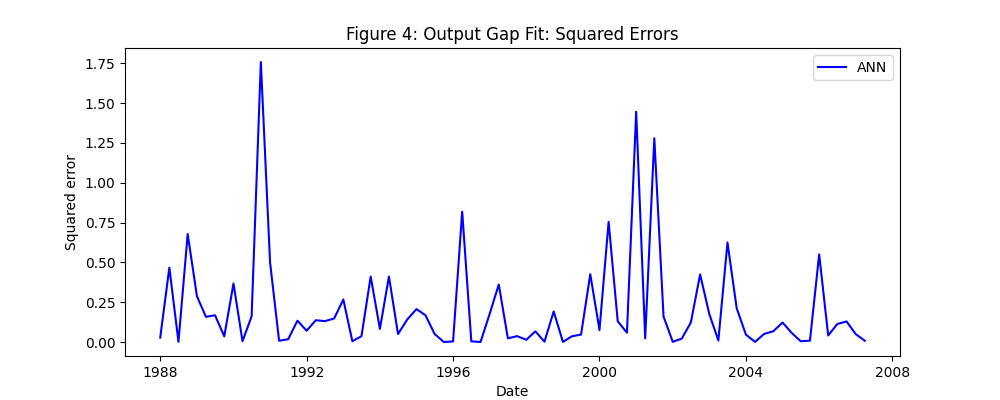

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    fit_narx.index.to_timestamp(),
    fit_narx["se_y_narx"],
    color="blue",
    linewidth=1.5,
    label="ANN",
)

ax.set_title("Figure 4: Output Gap Fit: Squared Errors")
ax.set_xlabel("Date")
ax.set_ylabel("Squared error")
ax.grid(False)
ax.legend()

plt.show()

figure_four_ann = fig

Note: This figure shows the squared errors between the actual output-gap time series (1988Q1 to 2007Q2 after lag alignment) and the fitted values of the ANN model.

### Figure 5: Inflation Fit — Squared Errors

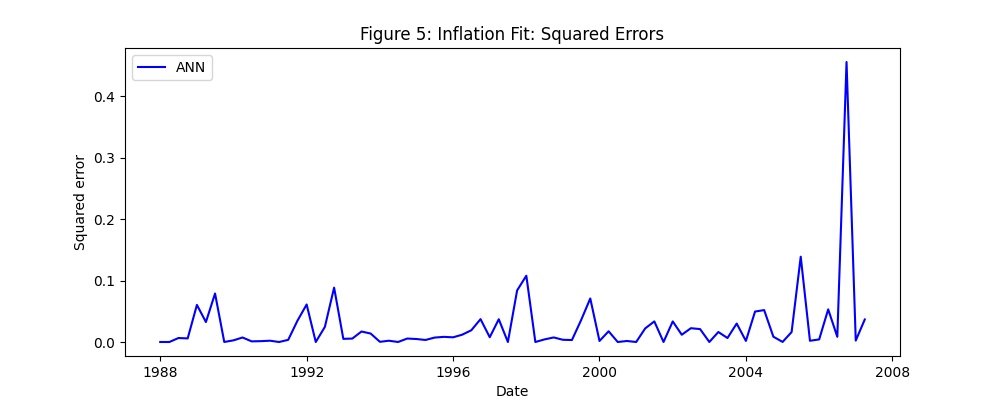

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    fit_narx.index.to_timestamp(),
    fit_narx["se_pi_narx"],
    color="blue",
    linewidth=1.5,
    label="ANN",
)

ax.set_title("Figure 5: Inflation Fit: Squared Errors")
ax.set_xlabel("Date")
ax.set_ylabel("Squared error")
ax.grid(False)
ax.legend()

plt.show()

figure_five_ann = fig

Note: This figure shows the squared errors between the inflation time series (1988Q1 to 2007Q2 after lag alignment) and the fitted values of the ANN model.

## Economy fit: mean squared errors

The following table summarizes the ANN model’s mean squared error for:

- the output-gap equation,
- the inflation equation,
- the overall economy representation, defined here as the simple average of the two equation-specific MSE values.

In [34]:
mse_y_ann = float(fit_narx["se_y_narx"].mean())
mse_pi_ann = float(fit_narx["se_pi_narx"].mean())
mse_total_ann = 0.5 * (mse_y_ann + mse_pi_ann)

table_ann_mse = pd.DataFrame(
    {
        "Representation": ["ANN"],
        "MSE Output Gap": [mse_y_ann],
        "MSE Inflation": [mse_pi_ann],
        "MSE Total": [mse_total_ann],
    }
)

table_ann_mse

,Representation,MSE Output Gap,MSE Inflation,MSE Total
0,ANN,0.206011,0.025238,0.115625


## Partial dependence surface plot — ANN economy, inflation

The next figure shows the partial dependence of inflation, $\pi_t$, on last period’s nominal interest rate $i_{t-1}$ and on the output gap, under the restriction

$$
y_t = y_{t-1} = y_{t-2},
$$

while marginalizing over lagged inflation by fixing

$$
\pi_{t-1} = \pi_{t-2} = \bar{\pi}.
$$

This is a partial dependence visualization of the fitted ANN mapping, not a structural impulse-response object.

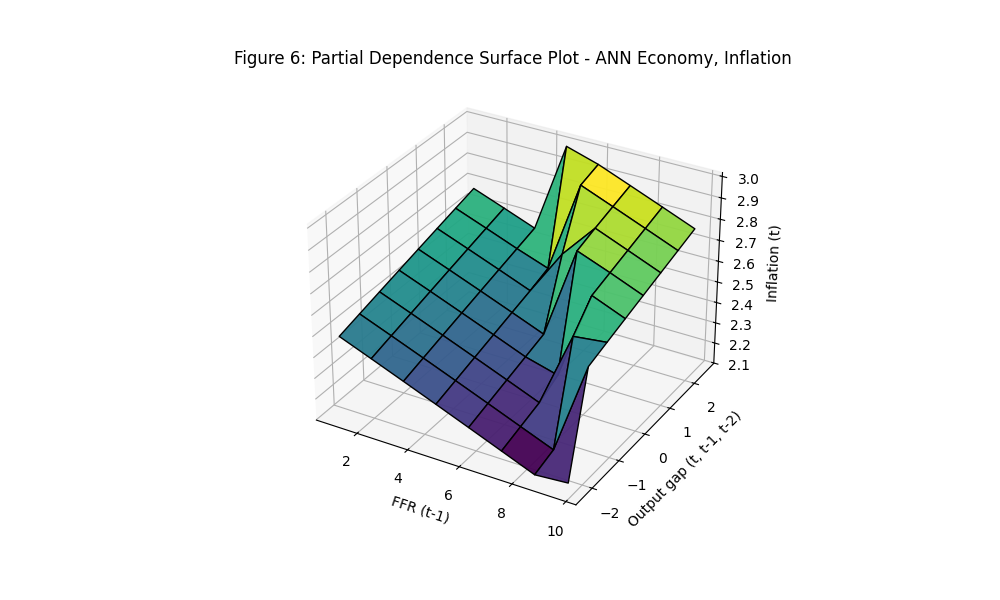

In [35]:
# Use observed support for the plotted axes
i_vals = np.linspace(float(df_nl["i"].min()), float(df_nl["i"].max()), 8)
y_vals = np.linspace(float(df_nl["y"].min()), float(df_nl["y"].max()), 8)

I, Y = np.meshgrid(i_vals, y_vals)
Z = np.zeros_like(I, dtype=float)

# Marginalize over inflation lags by fixing them at the sample mean
pi_mean = float(df_nl["pi"].mean())

for r in range(I.shape[0]):
    for c in range(I.shape[1]):
        y_val = float(Y[r, c])
        i_val = float(I[r, c])

        x = np.array([
            y_val,    # y_t
            y_val,    # y_{t-1}
            y_val,    # y_{t-2}
            pi_mean,  # pi_{t-1}
            pi_mean,  # pi_{t-2}
            i_val,    # i_{t-1}
        ]).reshape(1, -1)

        x_t = torch.tensor(x, dtype=DTYPE, device=DEVICE)
        x_scaled = x_scaler_pi.transform(x_t)

        with torch.no_grad():
            z_scaled = final_narx_pi(x_scaled)
            z = y_scaler_pi.inverse_transform(z_scaled)

        Z[r, c] = float(z.item())

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    I, Y, Z,
    cmap="viridis",
    edgecolor="k",
    linewidth=1.0,
    alpha=0.95
)

ax.set_title("Figure 6: Partial Dependence Surface Plot - ANN Economy, Inflation")
ax.set_xlabel("FFR (t-1)")
ax.set_ylabel("Output gap (t, t-1, t-2)")
ax.set_zlabel("Inflation (t)")

plt.show()

figure_six_ann = fig

Note: This figure shows the partial dependence of inflation, $\pi_t$, on last period’s nominal interest rate (FFR), $i_{t-1}$, and on the output gap, assuming $y_t = y_{t-1} = y_{t-2}$ and marginalizing over $\pi_{t-1} = \pi_{t-2}$.

## Partial dependence surface plot — ANN economy, output gap

The next figure shows the partial dependence of the output gap, $y_t$, on last period’s inflation $\pi_{t-1}$ and nominal interest rate $i_{t-1}$, while holding lagged output gap fixed at its sample mean:

$$
y_{t-1} = \bar{y}.
$$

This again visualizes the fitted ANN mapping rather than a structural or causal policy object.

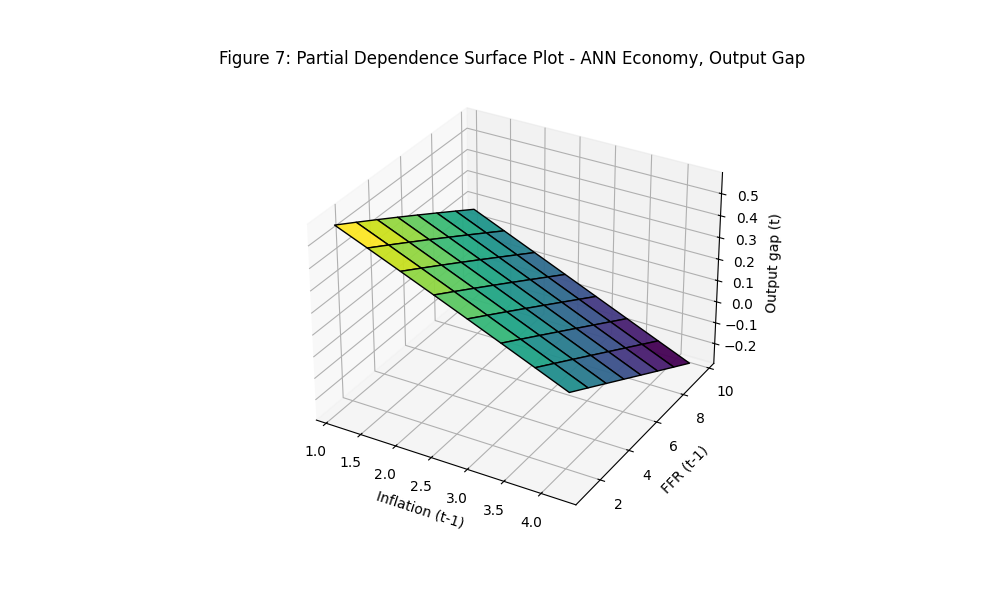

In [36]:
pi_vals = np.linspace(float(df_nl["pi"].min()), float(df_nl["pi"].max()), 8)
i_vals = np.linspace(float(df_nl["i"].min()), float(df_nl["i"].max()), 8)

PI, I = np.meshgrid(pi_vals, i_vals)
Z = np.zeros_like(PI, dtype=float)

# Hold lagged output gap fixed
y_mean = float(df_nl["y"].mean())

for r in range(PI.shape[0]):
    for c in range(PI.shape[1]):
        pi_val = float(PI[r, c])
        i_val = float(I[r, c])

        x = np.array([
            y_mean, # y_{t-1}
            pi_val, # pi_{t-1}
            i_val, # i_{t-1}
        ]).reshape(1, -1)

        x_t = torch.tensor(x, dtype=DTYPE, device=DEVICE)
        x_scaled = x_scaler_y.transform(x_t)

        with torch.no_grad():
            z_scaled = final_narx_y(x_scaled)
            z = y_scaler_y.inverse_transform(z_scaled)

        Z[r, c] = float(z.item())

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    PI, I, Z,
    cmap="viridis",
    edgecolor="k",
    linewidth=1.0,
    alpha=0.95
)

ax.set_title("Figure 7: Partial Dependence Surface Plot - ANN Economy, Output Gap")
ax.set_xlabel("Inflation (t-1)")
ax.set_ylabel("FFR (t-1)")
ax.set_zlabel("Output gap (t)")

plt.show()

figure_seven_ann = fig

Note: This figure shows the partial dependence of the output gap, $y_t$, on last period’s inflation, $\pi_{t-1}$, and nominal interest rate (FFR), assuming $y_{t-1} = \bar{y}$.

## Out-of-Sample ANN Fit — One-Step Actual vs Predicted Values (NARX)

To evaluate the nonlinear environment outside the estimation sample, we next generate one-step out-of-sample predictions for the NARX specification over the post-2007 period.

This evaluation reuses the retained output-gap and inflation networks selected by the hidden-unit search and fitted by Levenberg–Marquardt. Thus, the architecture, fitted weights, and equation-specific scaling objects are identical to those used in the training section. The only change is that the design matrices are now rebuilt over the out-of-sample period.

Because the NARX equations are evaluated directly on observed out-of-sample regressors, this is a one-step conditional out-of-sample assessment rather than a recursive simulation.

In [37]:
import datetime

# Forecasting data Time Period: Q3 2007 - Now
os_start_date = "2007-07-01"
os_end_date = datetime.date.today().strftime("%Y-%m-%d")

In [38]:
# Merge into one OOS DataFrame
df_oos = pd.concat([os_pi.rename("pi"), os_y_gap.rename("y"), os_i], axis=1).dropna().sort_index()
df_oos.index = df_oos.index.to_period("Q")

print(df_oos.head(), "\n")
print("OOS span:", df_oos.index.min(), "→", df_oos.index.max(), "| rows:", len(df_oos))

NameError: name 'os_pi' is not defined

In [ ]:
# Rebuild the restricted NARX design matrices on the out-of-sample sample.
# Since df_oos begins in 2007Q3, the lag-aligned design will begin in 2008Q1.

design_oos = build_restricted_narx_design_matrices(
    df=df_oos,
    dtype=DTYPE,
    device=DEVICE,
)

print("OOS output-gap design matrix:", design_oos.X_y.shape)
print("OOS output-gap target:", design_oos.y_target.shape)
print("OOS inflation design matrix:", design_oos.X_pi.shape)
print("OOS inflation target:", design_oos.pi_target.shape)
print("OOS lag-aligned span:", design_oos.time_index[0], "→", design_oos.time_index[-1])

OOS output-gap design matrix: torch.Size([72, 3])
OOS output-gap target: torch.Size([72, 1])
OOS inflation design matrix: torch.Size([72, 6])
OOS inflation target: torch.Size([72, 1])
OOS lag-aligned span: 2008Q1 → 2025Q4


The restricted NARX design is rebuilt on the out-of-sample sample using the same equation structure as in the estimation section:

- output-gap equation: $ y_t \leftarrow (y_{t-1}, \pi_{t-1}, i_{t-1}) $
- inflation equation: $ \pi_t \leftarrow (y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}) $

This preserves the baseline nonlinear specification while moving the evaluation window beyond the training period.

In [ ]:
# Scale the out-of-sample regressors and targets using the retained
# equation-specific scalers from the hidden-search-selected LM models.

X_y_oos_scaled = x_scaler_y.transform(design_oos.X_y)
y_y_oos_scaled = y_scaler_y.transform(design_oos.y_target)

X_pi_oos_scaled = x_scaler_pi.transform(design_oos.X_pi)
y_pi_oos_scaled = y_scaler_pi.transform(design_oos.pi_target)

# Generate one-step predictions in scaled space using the retained final NARX models.
with torch.no_grad():
    y_hat_oos_scaled = final_narx_y(X_y_oos_scaled)
    pi_hat_oos_scaled = final_narx_pi(X_pi_oos_scaled)

# Map predictions back to original units.
y_hat_oos = y_scaler_y.inverse_transform(y_hat_oos_scaled)
pi_hat_oos = y_scaler_pi.inverse_transform(pi_hat_oos_scaled)

print("OOS output-gap prediction shape:", tuple(y_hat_oos.shape))
print("OOS inflation prediction shape:", tuple(pi_hat_oos.shape))

OOS output-gap prediction shape: (72, 1)
OOS inflation prediction shape: (72, 1)


The out-of-sample regressors are transformed using the retained training-sample scaling objects, predictions are generated in scaled space, and the results are then mapped back into the original macroeconomic units.

This ensures that the out-of-sample evaluation uses the exact same learned nonlinear mappings selected in the hidden-search stage.

In [ ]:
fit_narx_oos_1step = pd.DataFrame(
    {
        "y_actual": design_oos.y_target.detach().cpu().numpy().reshape(-1),
        "y_hat": y_hat_oos.detach().cpu().numpy().reshape(-1),
        "pi_actual": design_oos.pi_target.detach().cpu().numpy().reshape(-1),
        "pi_hat": pi_hat_oos.detach().cpu().numpy().reshape(-1),
    },
    index=pd.Index(design_oos.time_index, name="date"),
).sort_index()

fit_narx_oos_1step["resid_y_narx"] = (
    fit_narx_oos_1step["y_actual"] - fit_narx_oos_1step["y_hat"]
)
fit_narx_oos_1step["resid_pi_narx"] = (
    fit_narx_oos_1step["pi_actual"] - fit_narx_oos_1step["pi_hat"]
)
fit_narx_oos_1step["se_y_narx"] = fit_narx_oos_1step["resid_y_narx"] ** 2
fit_narx_oos_1step["se_pi_narx"] = fit_narx_oos_1step["resid_pi_narx"] ** 2

print(fit_narx_oos_1step.head())
print(fit_narx_oos_1step.tail())
print("One-step OOS span:", fit_narx_oos_1step.index.min(), "→", fit_narx_oos_1step.index.max())

        y_actual     y_hat  pi_actual    pi_hat  resid_y_narx  resid_pi_narx  \
date                                                                           
2008Q1  0.406716  1.358930    2.03211  2.691189     -0.952214      -0.659079   
2008Q2  0.527217  0.592701    1.81848  1.647931     -0.065484       0.170549   
2008Q3 -0.445713  0.797225    2.02788  1.866923     -1.242938       0.160957   
2008Q4 -3.026831 -0.347533    1.86222  2.314615     -2.679298      -0.452395   
2009Q1 -4.486292 -2.117205    1.40640  1.710405     -2.369088      -0.304005   

        se_y_narx  se_pi_narx  
date                           
2008Q1   0.906711    0.434386  
2008Q2   0.004288    0.029087  
2008Q3   1.544895    0.025907  
2008Q4   7.178638    0.204662  
2009Q1   5.612576    0.092419  
        y_actual     y_hat  pi_actual    pi_hat  resid_y_narx  resid_pi_narx  \
date                                                                           
2024Q4  1.353586  1.498731    2.46749  2.526331     -0.

To mirror the in-sample ANN diagnostics, the one-step out-of-sample predictions are collected in a single aligned dataframe containing:

- realized output gap,
- predicted output gap,
- realized inflation,
- predicted inflation,
- residuals, and
- squared errors.

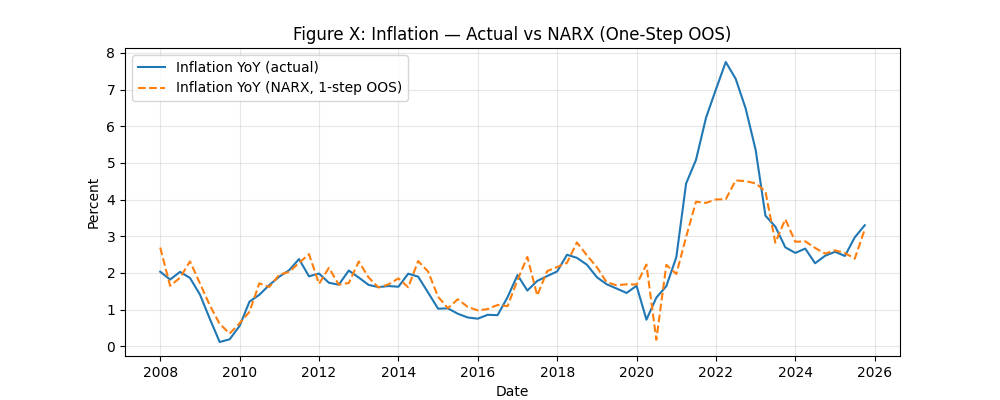

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    fit_narx_oos_1step.index.to_timestamp(),
    fit_narx_oos_1step["pi_actual"],
    label="Inflation YoY (actual)",
)

ax.plot(
    fit_narx_oos_1step.index.to_timestamp(),
    fit_narx_oos_1step["pi_hat"],
    "--",
    label="Inflation YoY (NARX, 1-step OOS)",
)

ax.set_title("Figure X: Inflation — Actual vs NARX (One-Step OOS)")
ax.set_xlabel("Date")
ax.set_ylabel("Percent")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

figure_inflation_narx_oos_1step = fig

**Note:** This figure shows the realized output gap and the one-step out-of-sample NARX predictions over the post-2007 evaluation period.

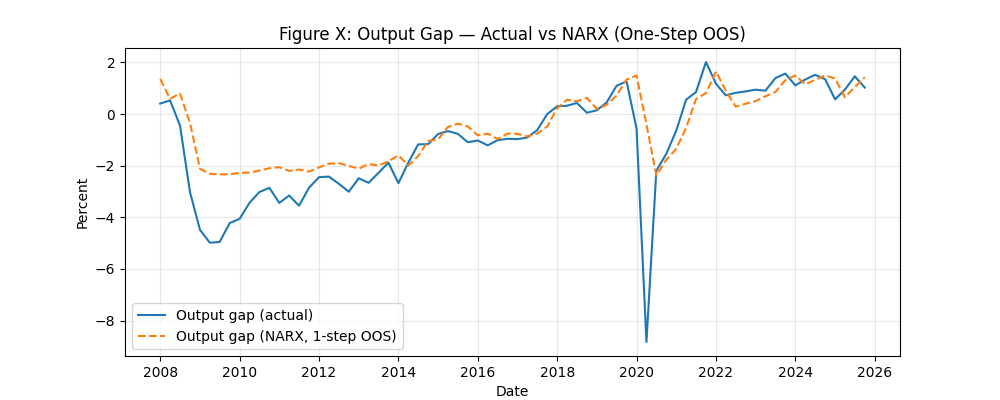

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    fit_narx_oos_1step.index.to_timestamp(),
    fit_narx_oos_1step["y_actual"],
    label="Output gap (actual)",
)

ax.plot(
    fit_narx_oos_1step.index.to_timestamp(),
    fit_narx_oos_1step["y_hat"],
    "--",
    label="Output gap (NARX, 1-step OOS)",
)

ax.set_title("Figure X: Output Gap — Actual vs NARX (One-Step OOS)")
ax.set_xlabel("Date")
ax.set_ylabel("Percent")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

figure_output_gap_narx_oos_1step = fig

**Note:** This figure shows the realized inflation series and the one-step out-of-sample NARX predictions over the post-2007 evaluation period.

-------------

# Modern Specification: Neural State Space Model

To extend the nonlinear environment beyond static function approximation, we introduce a neural state space model (NSSM). This specification generalizes the classical state-space framework by allowing nonlinear transition and measurement mappings parameterized by neural networks rather than fixed linear operators (Durbin & Koopman, 2012; Fraccaro et al., 2016).

Relative to the NARX specification, which maps explicit lagged observables into current outcomes, the NSSM introduces a latent state that evolves recursively through time. This provides a more modern dynamical representation of the economy while retaining a compact recursive system suitable for forecasting and policy-environment approximation (Krishnan et al., 2017; Rangapuram et al., 2018).

## State-space formulation

Let $h_t^y \in {\mathbb{R}^{d_y}}$ and $h_t^\pi \in \mathbb{R}^{d_\pi}$ denote equation-specific latent states for the output-gap and inflation blocks, respectively. To maintain comparability with the full-information benchmark system, the neural state-space model uses the same full regressor sets as the unrestricted second-order linear environment.

Define

$$
s_t^y = (y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2}),
$$

and

$$
s_t^\pi = (y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2}).
$$

The deterministic neural state-space system is then written as

$$
\begin{aligned}
h_t^y &= f_y(h_{t-1}^y, s_t^y), \\
y_t &= g_y(h_t^y),
\end{aligned}
\qquad
\begin{aligned}
h_t^\pi &= f_\pi(h_{t-1}^\pi, s_t^\pi), \\
\pi_t &= g_\pi(h_t^\pi).
\end{aligned}
$$

This preserves the recursive macroeconomic logic of the earlier environments while replacing explicit lag stacks with a learned latent state (Durbin & Koopman, 2012; Fraccaro et al., 2016).

## Relation to the linear and NARX environments


The NSSM preserves the full observable information set used in the unrestricted second-order system, while introducing latent states that evolve dynamically over time.

In contrast to the earlier NARX specification, which treats the mapping from lagged variables to current outcomes as static, the NSSM allows for dynamic nonlinear propagation through the latent state. At the same time, by retaining the full regressor vectors $ s_t^y $ and $ s_t^\pi $, the model avoids placing excessive informational burden on the latent state.

This hybrid structure can therefore be interpreted as a state-space generalization of the nonlinear regression model, rather than a fully latent system (Krishnan et al., 2017; Rangapuram et al., 2018).

## Deterministic training setup

Given the limited sample size, we estimate a deterministic version of the NSSM. That is, we omit explicit stochastic disturbance terms and instead train the model via supervised sequence fitting.

This approach avoids the additional complexity of latent-state inference while retaining the key advantage of the state-space formulation: recursive temporal structure (Fraccaro et al., 2016; Krishnan et al., 2017).

## Functional parameterization

We parameterize the transition and emission equations using shallow neural mappings:

$$
\begin{aligned}
h_t^y &= \operatorname{SiLU}(W_h^y h_{t-1}^y + W_x^y s_t^y + b_h^y), \\
y_t &= W_o^y h_t^y + b_o^y,
\end{aligned}
$$

and

$$
\begin{aligned}
h_t^\pi &= \operatorname{SiLU}(W_h^\pi h_{t-1}^\pi + W_x^\pi s_t^\pi + b_h^\pi), \\
\pi_t &= W_o^\pi h_t^\pi + b_o^\pi.
\end{aligned}
$$

The transition nonlinearity is the Sigmoid Linear Unit (SiLU), defined as

$$
\operatorname{SiLU}(x) = x \cdot \sigma(x).
$$

SiLU is chosen because it is smooth, differentiable, and empirically effective in modern neural architectures, while avoiding the saturation behavior of earlier bounded nonlinearities such as tanh (Elfwing et al., 2018; Ramachandran et al., 2018).

## Initialization strategy

The transition matrices $W_h^y$ and $W_h^\pi$ are initialized orthogonally, while the input and emission layers use Xavier initialization.

Orthogonal initialization is particularly natural for latent transition operators because it helps preserve signal scale and improves optimization in sequential or recurrent settings (Saxe et al., 2014; Hu et al., 2020). Xavier initialization is used for the remaining linear layers to stabilize variance propagation across inputs and outputs (Glorot & Bengio, 2010).

This combination provides a modern alternative to the Nguyen–Widrow initialization used in the earlier shallow NARX section.

## Optimization

The NSSM is estimated using AdamW rather than Levenberg–Marquardt. AdamW decouples weight decay from the gradient update and is now a standard first-order optimizer for modern neural-network training (Loshchilov & Hutter, 2019).

The training objective is the joint mean squared error across the two observed macroeconomic series:

$$
\mathcal{L}
=
\frac{1}{T}
\sum_{t=1}^{T}
\left[
(y_t - \hat{y}_t)^2
+
(\pi_t - \hat{\pi}_t)^2
\right].
$$

Because the model is recursive in the latent state, training is carried out over the full sequence rather than on independent observations.

In [ ]:
class TwoBlockNSSM(nn.Module):
    def __init__(self, state_dim_y: int, state_dim_pi: int, input_dim_y: int, input_dim_pi: int):
        super().__init__()

        self.W_h_y = nn.Linear(state_dim_y, state_dim_y)
        self.W_x_y = nn.Linear(input_dim_y, state_dim_y)
        self.W_o_y = nn.Linear(state_dim_y, 1)

        self.W_h_pi = nn.Linear(state_dim_pi, state_dim_pi)
        self.W_x_pi = nn.Linear(input_dim_pi, state_dim_pi)
        self.W_o_pi = nn.Linear(state_dim_pi, 1)

        self.activation = nn.SiLU()

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.orthogonal_(self.W_h_y.weight)
        nn.init.orthogonal_(self.W_h_pi.weight)

        nn.init.xavier_uniform_(self.W_x_y.weight)
        nn.init.xavier_uniform_(self.W_x_pi.weight)
        nn.init.xavier_uniform_(self.W_o_y.weight)
        nn.init.xavier_uniform_(self.W_o_pi.weight)

    def forward(self, h_y: torch.Tensor, h_pi: torch.Tensor, x_y: torch.Tensor, x_pi: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        h_y = self.activation(self.W_h_y(h_y) + self.W_x_y(x_y))
        y_t = self.W_o_y(h_y)

        h_pi = self.activation(self.W_h_pi(h_pi) + self.W_x_pi(x_pi))
        pi_t = self.W_o_pi(h_pi)

        return h_y, h_pi, y_t, pi_t

## Sequence propagation

The NSSM is evaluated recursively over the lag-aligned sample by iterating the transition equation forward through time. At each quarter, the latent state is updated using the previous latent state and the observed lagged policy rate, and the current output gap and inflation are obtained from the emission equations.

In [ ]:
def run_nssm_sequence(model: TwoBlockNSSM, X_y: torch.Tensor, X_pi: torch.Tensor, h0_y: torch.Tensor, h0_pi: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Roll the two-block NSSM forward over the full sample.

    Args:
        model: Fitted two-block NSSM model.
        X_y: Output-gap regressor sequence of shape (T, input_dim_y).
        X_pi: Inflation regressor sequence of shape (T, input_dim_pi).
        h0_y: Initial output-gap latent state of shape (1, state_dim_y).
        h0_pi: Initial inflation latent state of shape (1, state_dim_pi).

    Returns:
        Tuple containing:
            - predicted output-gap path of shape (T, 1)
            - predicted inflation path of shape (T, 1)
            - output-gap latent-state path of shape (T, state_dim_y)
            - inflation latent-state path of shape (T, state_dim_pi)
    """
    X_y = _to_2d_tensor(X_y)
    X_pi = _to_2d_tensor(X_pi)

    if X_y.shape[0] != X_pi.shape[0]:
        raise ValueError("X_y and X_pi must have the same number of rows.")

    h_y = _to_2d_tensor(h0_y)
    h_pi = _to_2d_tensor(h0_pi)

    y_preds: List[torch.Tensor] = []
    pi_preds: List[torch.Tensor] = []
    states_y: List[torch.Tensor] = []
    states_pi: List[torch.Tensor] = []

    for t in range(X_y.shape[0]):
        x_y_t = X_y[t:t + 1]
        x_pi_t = X_pi[t:t + 1]

        h_y, h_pi, y_t, pi_t = model(
            h_y,
            h_pi,
            x_y_t,
            x_pi_t,
        )

        y_preds.append(y_t)
        pi_preds.append(pi_t)
        states_y.append(h_y)
        states_pi.append(h_pi)

    return (
        torch.cat(y_preds, dim=0),
        torch.cat(pi_preds, dim=0),
        torch.cat(states_y, dim=0),
        torch.cat(states_pi, dim=0),
    )

## Data used for the state-space model

To keep the NSSM directly comparable to the earlier nonlinear specification, we use the same lag-aligned sample span as the NARX environment. The sequence input is the lagged policy rate $ i_{t-1} $, while the targets are the realized output gap and inflation series over the same aligned quarters.

In [ ]:
@dataclass
class FullNSSMInputs:
    """Container for full-regressor NSSM inputs."""
    X_y: torch.Tensor
    y_target: torch.Tensor
    X_pi: torch.Tensor
    pi_target: torch.Tensor
    time_index: list


def build_full_nssm_inputs(df: pd.DataFrame, *, dtype: torch.dtype = torch.float64, device: Optional[torch.device] = None) -> FullNSSMInputs:
    """
    Build full-information NSSM input sequences.

    Output-gap block:
        s_t^y = [y_{t-1}, y_{t-2}, pi_{t-1}, pi_{t-2}, i_{t-1}, i_{t-2}]

    Inflation block:
        s_t^pi = [y_t, y_{t-1}, y_{t-2}, pi_{t-1}, pi_{t-2}, i_{t-1}, i_{t-2}]
    """
    required = {"y", "pi", "i"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"df is missing required columns: {sorted(missing)}")

    work = df.loc[:, ["y", "pi", "i"]].copy().sort_index()

    rows_y = []
    rows_pi = []
    y_targets = []
    pi_targets = []
    time_index = []

    for t in range(2, len(work)):
        y_t = float(work["y"].iloc[t])
        pi_t = float(work["pi"].iloc[t])

        y_l1 = float(work["y"].iloc[t - 1])
        y_l2 = float(work["y"].iloc[t - 2])

        pi_l1 = float(work["pi"].iloc[t - 1])
        pi_l2 = float(work["pi"].iloc[t - 2])

        i_l1 = float(work["i"].iloc[t - 1])
        i_l2 = float(work["i"].iloc[t - 2])

        x_y_t = [y_l1, y_l2, pi_l1, pi_l2, i_l1, i_l2]
        x_pi_t = [y_t, y_l1, y_l2, pi_l1, pi_l2, i_l1, i_l2]

        rows_y.append(x_y_t)
        rows_pi.append(x_pi_t)
        y_targets.append([y_t])
        pi_targets.append([pi_t])
        time_index.append(work.index[t])

    return FullNSSMInputs(
        X_y=torch.tensor(rows_y, dtype=dtype, device=device),
        y_target=torch.tensor(y_targets, dtype=dtype, device=device),
        X_pi=torch.tensor(rows_pi, dtype=dtype, device=device),
        pi_target=torch.tensor(pi_targets, dtype=dtype, device=device),
        time_index=time_index,
    )

In [ ]:
nssm_inputs = build_full_nssm_inputs(df=df_train, dtype=DTYPE, device=DEVICE)

X_y_nssm = nssm_inputs.X_y
y_target_nssm = nssm_inputs.y_target

X_pi_nssm = nssm_inputs.X_pi
pi_target_nssm = nssm_inputs.pi_target

time_index_nssm = nssm_inputs.time_index

print("NSSM output-gap input shape:", tuple(X_y_nssm.shape))
print("NSSM inflation input shape:", tuple(X_pi_nssm.shape))
print("NSSM output-gap target shape:", tuple(y_target_nssm.shape))
print("NSSM inflation target shape:", tuple(pi_target_nssm.shape))
print("NSSM sample span:", time_index_nssm[0], "→", time_index_nssm[-1])

NSSM output-gap input shape: (78, 6)
NSSM inflation input shape: (78, 7)
NSSM output-gap target shape: (78, 1)
NSSM inflation target shape: (78, 1)
NSSM sample span: 1988Q1 → 2007Q2


## Model estimation

The NSSM is estimated using the AdamW optimizer, which decouples weight decay from gradient updates and improves generalization relative to standard Adam (Loshchilov & Hutter, 2019).

The objective function is the joint mean squared error:

$$
\mathcal{L}
=
\frac{1}{T}
\sum_{t=1}^{T}
\left[
(y_t - \hat{y}_t)^2
+
(\pi_t - \hat{\pi}_t)^2
\right].
$$

Training is performed over the full sequence, preserving the recursive evolution of the latent state.

In [ ]:
def run_two_block_nssm_sequence(model: TwoBlockNSSM, X_y: torch.Tensor, X_pi: torch.Tensor, h0_y: torch.Tensor, h0_pi: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Roll the two-block NSSM forward over the full sample.

    Args:
        model: Fitted two-block NSSM model.
        X_y: Output-gap regressor sequence of shape (T, input_dim_y).
        X_pi: Inflation regressor sequence of shape (T, input_dim_pi).
        h0_y: Initial output-gap latent state of shape (1, state_dim_y).
        h0_pi: Initial inflation latent state of shape (1, state_dim_pi).

    Returns:
        Tuple containing:
            - predicted output-gap path of shape (T, 1)
            - predicted inflation path of shape (T, 1)
            - output-gap latent-state path of shape (T, state_dim_y)
            - inflation latent-state path of shape (T, state_dim_pi)
    """
    X_y = _to_2d_tensor(X_y)
    X_pi = _to_2d_tensor(X_pi)
    h_y = _to_2d_tensor(h0_y)
    h_pi = _to_2d_tensor(h0_pi)

    if X_y.shape[0] != X_pi.shape[0]:
        raise ValueError("X_y and X_pi must have the same number of rows.")

    y_preds: List[torch.Tensor] = []
    pi_preds: List[torch.Tensor] = []
    states_y: List[torch.Tensor] = []
    states_pi: List[torch.Tensor] = []

    for t in range(X_y.shape[0]):
        x_y_t = X_y[t:t + 1]
        x_pi_t = X_pi[t:t + 1]

        h_y, h_pi, y_t, pi_t = model(
            h_y,
            h_pi,
            x_y_t,
            x_pi_t,
        )

        y_preds.append(y_t)
        pi_preds.append(pi_t)
        states_y.append(h_y)
        states_pi.append(h_pi)

    return (
        torch.cat(y_preds, dim=0),
        torch.cat(pi_preds, dim=0),
        torch.cat(states_y, dim=0),
        torch.cat(states_pi, dim=0),
    )

In [ ]:
state_dim_y = 4
state_dim_pi = 4

nssm = TwoBlockNSSM(
    state_dim_y=state_dim_y,
    state_dim_pi=state_dim_pi,
    input_dim_y=X_y_nssm.shape[1],
    input_dim_pi=X_pi_nssm.shape[1],
).to(device=DEVICE, dtype=DTYPE)

optimizer = torch.optim.AdamW(
    nssm.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

h0_y_nssm = torch.zeros((1, state_dim_y), dtype=DTYPE, device=DEVICE)
h0_pi_nssm = torch.zeros((1, state_dim_pi), dtype=DTYPE, device=DEVICE)

n_epochs_nssm = 1000
loss_history_nssm: List[float] = []

for epoch in range(n_epochs_nssm):
    optimizer.zero_grad()

    y_hat_nssm, pi_hat_nssm, states_y_nssm, states_pi_nssm = run_two_block_nssm_sequence(
        model=nssm,
        X_y=X_y_nssm,
        X_pi=X_pi_nssm,
        h0_y=h0_y_nssm,
        h0_pi=h0_pi_nssm,
    )

    loss_y_nssm = torch.mean((y_hat_nssm - y_target_nssm) ** 2)
    loss_pi_nssm = torch.mean((pi_hat_nssm - pi_target_nssm) ** 2)
    loss_nssm = loss_y_nssm + loss_pi_nssm

    loss_nssm.backward()
    optimizer.step()

    loss_history_nssm.append(float(loss_nssm.item()))

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:04d} | "
            f"loss={loss_nssm.item():.8f} | "
            f"loss_y={loss_y_nssm.item():.8f} | "
            f"loss_pi={loss_pi_nssm.item():.8f}"
        )

Epoch 0000 | loss=830.32387177 | loss_y=3.02487841 | loss_pi=827.29899337
Epoch 0100 | loss=200.71297687 | loss_y=0.97832414 | loss_pi=199.73465273
Epoch 0200 | loss=74.03602253 | loss_y=0.54796532 | loss_pi=73.48805721
Epoch 0300 | loss=20.78924971 | loss_y=0.39078990 | loss_pi=20.39845981
Epoch 0400 | loss=14.59492043 | loss_y=0.32313693 | loss_pi=14.27178350
Epoch 0500 | loss=7.80987915 | loss_y=0.28387969 | loss_pi=7.52599945
Epoch 0600 | loss=1.35001410 | loss_y=0.25765265 | loss_pi=1.09236145
Epoch 0700 | loss=0.86561281 | loss_y=0.23888147 | loss_pi=0.62673133
Epoch 0800 | loss=0.73240612 | loss_y=0.22474555 | loss_pi=0.50766057
Epoch 0900 | loss=0.65148846 | loss_y=0.21307301 | loss_pi=0.43841544


## Fitted values and diagnostics

To maintain comparability with the linear and NARX environments, fitted values are collected in a single aligned dataframe and converted into squared-error diagnostics for both equations.

In [ ]:
with torch.no_grad():
    y_hat_nssm, pi_hat_nssm, states_y_nssm, states_pi_nssm = run_two_block_nssm_sequence(
        model=nssm,
        X_y=X_y_nssm,
        X_pi=X_pi_nssm,
        h0_y=h0_y_nssm,
        h0_pi=h0_pi_nssm,
    )

fit_nssm = pd.DataFrame(
    {
        "y_actual": y_target_nssm.detach().cpu().numpy().reshape(-1),
        "y_fit": y_hat_nssm.detach().cpu().numpy().reshape(-1),
        "pi_actual": pi_target_nssm.detach().cpu().numpy().reshape(-1),
        "pi_fit": pi_hat_nssm.detach().cpu().numpy().reshape(-1),
    },
    index=pd.Index(time_index_nssm, name="date"),
).sort_index()

fit_nssm["resid_y_nssm"] = fit_nssm["y_actual"] - fit_nssm["y_fit"]
fit_nssm["resid_pi_nssm"] = fit_nssm["pi_actual"] - fit_nssm["pi_fit"]

fit_nssm["se_y_nssm"] = fit_nssm["resid_y_nssm"] ** 2
fit_nssm["se_pi_nssm"] = fit_nssm["resid_pi_nssm"] ** 2

print(fit_nssm.head())

        y_actual     y_fit  pi_actual    pi_fit  resid_y_nssm  resid_pi_nssm  \
date                                                                           
1988Q1  0.370773  0.287330    3.06577  0.063505      0.083443       3.002265   
1988Q2  0.932239  0.438329    3.35274  2.032941      0.493911       1.319799   
1988Q3  0.779457  0.716705    3.80207  2.806918      0.062753       0.995152   
1988Q4  1.379886  0.888207    3.87063  2.938220      0.491679       0.932410   
1989Q1  1.673378  1.001044    4.13782  3.354885      0.672334       0.782935   

        se_y_nssm  se_pi_nssm  
date                           
1988Q1   0.006963    9.013593  
1988Q2   0.243948    1.741869  
1988Q3   0.003938    0.990327  
1988Q4   0.241748    0.869389  
1989Q1   0.452033    0.612988  


## Economy fit: mean squared errors

As in the ANN section above, we summarize the NSSM fit using equation-specific and overall mean squared errors.

In [ ]:
mse_y_nssm = float(fit_nssm["se_y_nssm"].mean())
mse_pi_nssm = float(fit_nssm["se_pi_nssm"].mean())
mse_total_nssm = 0.5 * (mse_y_nssm + mse_pi_nssm)

table_nssm_mse = pd.DataFrame(
    {
        "Representation": ["NSSM"],
        "MSE Output Gap": [mse_y_nssm],
        "MSE Inflation": [mse_pi_nssm],
        "MSE Total": [mse_total_nssm],
    }
)

table_nssm_mse

,Representation,MSE Output Gap,MSE Inflation,MSE Total
0,NSSM,0.203481,0.388388,0.295935


### Figure 8: Output Gap Fit — Squared Errors

The next figure reports squared errors for the output-gap equation under the neural state-space specification.

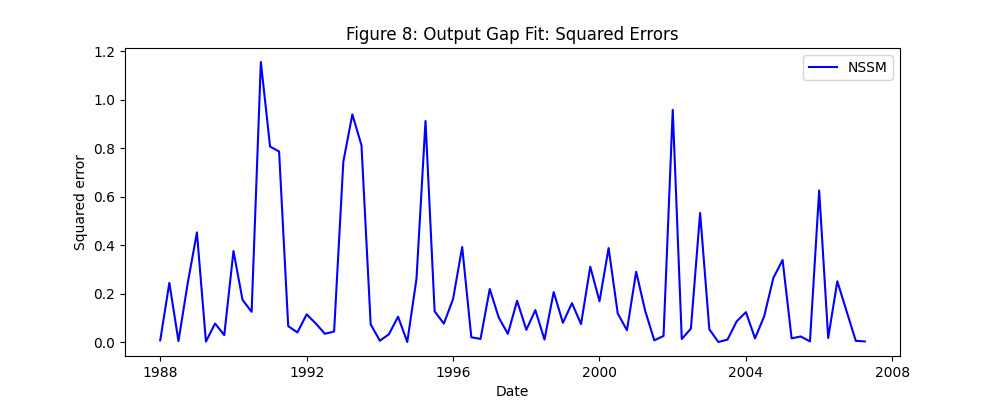

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    fit_nssm.index.to_timestamp(),
    fit_nssm["se_y_nssm"],
    color="blue",
    linewidth=1.5,
    label="NSSM",
)
ax.set_title("Figure 8: Output Gap Fit: Squared Errors")
ax.set_xlabel("Date")
ax.set_ylabel("Squared error")
ax.grid(False)
ax.legend()

plt.show()
figure_eight_nssm = fig

Note: This figure shows the squared errors between the actual output-gap time series (1988Q1 to 2007Q2 after lag alignment) and the fitted values of the NSSM model.

### Figure 9: Inflation Fit — Squared Errors

The next figure reports squared errors for the inflation equation under the neural state-space specification.

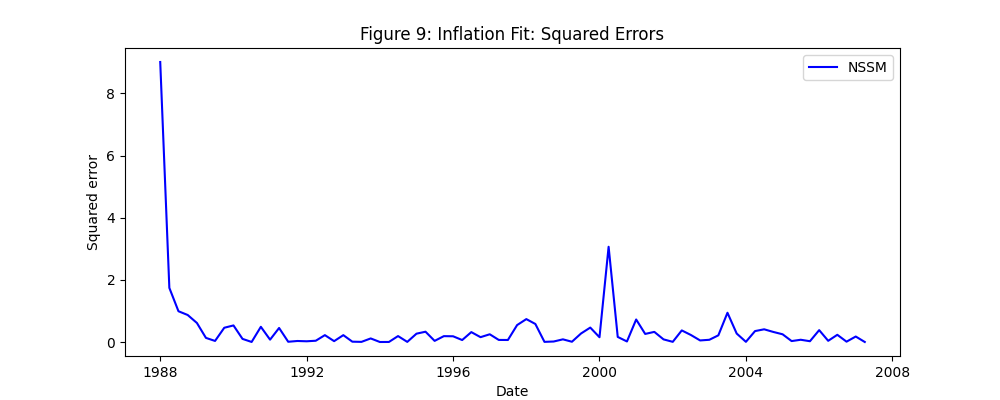

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    fit_nssm.index.to_timestamp(),
    fit_nssm["se_pi_nssm"],
    color="blue",
    linewidth=1.5,
    label="NSSM",
)
ax.set_title("Figure 9: Inflation Fit: Squared Errors")
ax.set_xlabel("Date")
ax.set_ylabel("Squared error")
ax.grid(False)
ax.legend()

plt.show()
figure_nine_nssm = fig

Note: This figure shows the squared errors between the inflation time series (1988Q1 to 2007Q2 after lag alignment) and the fitted values of the NSSM model.

## State-Conditioned Response Surface — NSSM Inflation

Because the neural state-space model evolves through a latent recursive state, a standard partial dependence surface is less informative than in the earlier NARX setting. Instead, we construct a **state-conditioned response surface**.

The idea is to fix the inflation block's latent state at a chosen historical quarter and then vary selected observed inputs while holding the remaining regressors fixed at their anchor-quarter values. The resulting surface shows how the fitted NSSM maps those inputs into the next inflation prediction **conditional on the chosen latent state**.

This is therefore a local state-dependent visualization of the nonlinear state-space environment rather than a global static partial dependence object.

In [ ]:
# Ensure the latent-state paths are available from the fitted NSSM.
with torch.no_grad():
    y_hat_nssm, pi_hat_nssm, states_y_nssm, states_pi_nssm = run_two_block_nssm_sequence(
        model=nssm,
        X_y=X_y_nssm,
        X_pi=X_pi_nssm,
        h0_y=h0_y_nssm,
        h0_pi=h0_pi_nssm,
    )

print("states_y_nssm shape:", tuple(states_y_nssm.shape))
print("states_pi_nssm shape:", tuple(states_pi_nssm.shape))
print("time span:", time_index_nssm[0], "→", time_index_nssm[-1])

states_y_nssm shape: (78, 4)
states_pi_nssm shape: (78, 4)
time span: 1988Q1 → 2007Q2


To make the visualization concrete, we select one historical anchor quarter from the fitted sample. The latent state from that quarter is held fixed, and the remaining surface is computed relative to that anchor configuration.

In [ ]:
# Choose an anchor quarter for the state-conditioned surface.
# Default: midpoint of the in-sample lag-aligned sample.
anchor_idx = len(time_index_nssm) // 2
anchor_period = time_index_nssm[anchor_idx]

print("Anchor period:", anchor_period)

Anchor period: 1997Q4


In [ ]:
# Extract the anchor latent states and anchor regressors.
h_y_anchor = states_y_nssm[anchor_idx:anchor_idx + 1].clone()
h_pi_anchor = states_pi_nssm[anchor_idx:anchor_idx + 1].clone()

x_y_anchor = X_y_nssm[anchor_idx:anchor_idx + 1].clone()
x_pi_anchor = X_pi_nssm[anchor_idx:anchor_idx + 1].clone()

print("h_y_anchor shape:", tuple(h_y_anchor.shape))
print("h_pi_anchor shape:", tuple(h_pi_anchor.shape))
print("x_y_anchor:", x_y_anchor)
print("x_pi_anchor:", x_pi_anchor)

h_y_anchor shape: (1, 4)
h_pi_anchor shape: (1, 4)
x_y_anchor: tensor([[1.4099, 1.1397, 1.7773, 1.6670, 5.5300, 5.5200]], dtype=torch.float64)
x_pi_anchor: tensor([[1.2629, 1.4099, 1.1397, 1.7773, 1.6670, 5.5300, 5.5200]],
       dtype=torch.float64)


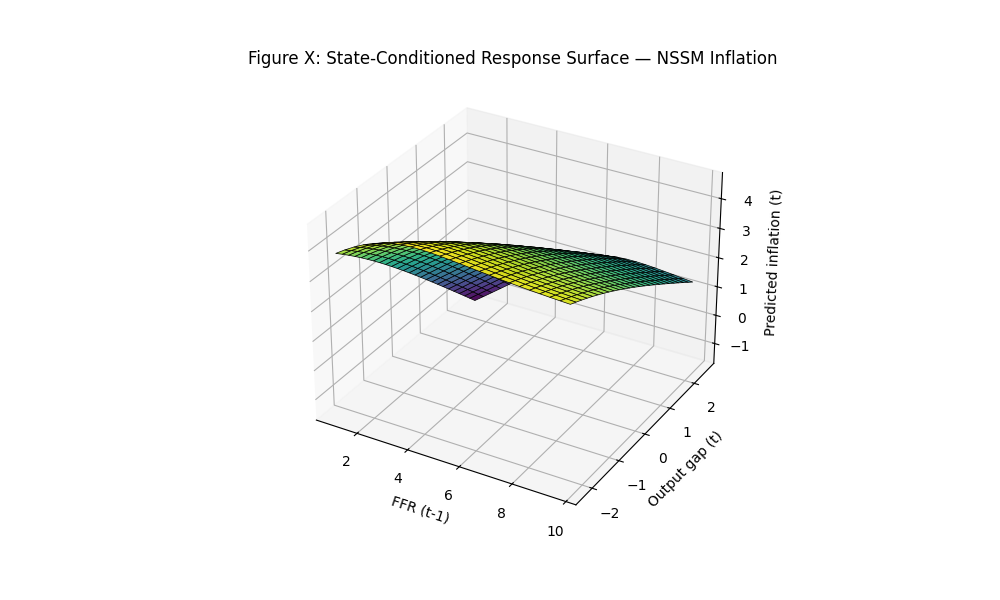

In [ ]:
# State-conditioned inflation response surface:
# Vary contemporaneous output gap y_t and lagged policy rate i_{t-1},
# while holding the remaining inflation-block regressors fixed at their anchor values.

y_vals = np.linspace(float(df_train["y"].min()), float(df_train["y"].max()), 25)
i_vals = np.linspace(float(df_train["i"].min()), float(df_train["i"].max()), 25)

Y_GRID, I_GRID = np.meshgrid(y_vals, i_vals)
Z_PI = np.zeros_like(Y_GRID, dtype=float)

nssm.eval()
with torch.no_grad():
    for r in range(Y_GRID.shape[0]):
        for c in range(Y_GRID.shape[1]):
            y_t_val = float(Y_GRID[r, c])
            i_lag1_val = float(I_GRID[r, c])

            # Inflation-block regressor order:
            # [y_t, y_{t-1}, y_{t-2}, pi_{t-1}, pi_{t-2}, i_{t-1}, i_{t-2}]
            x_pi_grid = x_pi_anchor.clone()
            x_pi_grid[0, 0] = y_t_val
            x_pi_grid[0, 5] = i_lag1_val

            # Keep the output-gap block frozen at anchor inputs/state.
            _, _, _, pi_t_grid = nssm(
                h_y_anchor,
                h_pi_anchor,
                x_y_anchor,
                x_pi_grid,
            )

            Z_PI[r, c] = float(pi_t_grid.item())

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    I_GRID,
    Y_GRID,
    Z_PI,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.5,
    alpha=0.95,
)

ax.set_title("Figure X: State-Conditioned Response Surface — NSSM Inflation")
ax.set_xlabel("FFR (t-1)")
ax.set_ylabel("Output gap (t)")
ax.set_zlabel("Predicted inflation (t)")

plt.show()

figure_nssm_state_conditioned_pi = fig

**Note:** This figure conditions on the inflation block's latent state at the anchor quarter and shows how the fitted NSSM's inflation prediction varies with contemporaneous output gap and the lagged policy rate, while all remaining regressors are fixed at their anchor-quarter values.

## State-Conditioned Response Surface — NSSM Output Gap

We next construct the analogous state-conditioned response surface for the output-gap block. Again, the latent state is fixed at the anchor quarter, while selected observed inputs are varied over their empirical support and the remaining regressors are held fixed.

This produces a local state-dependent visualization of the NSSM's output-gap mapping.

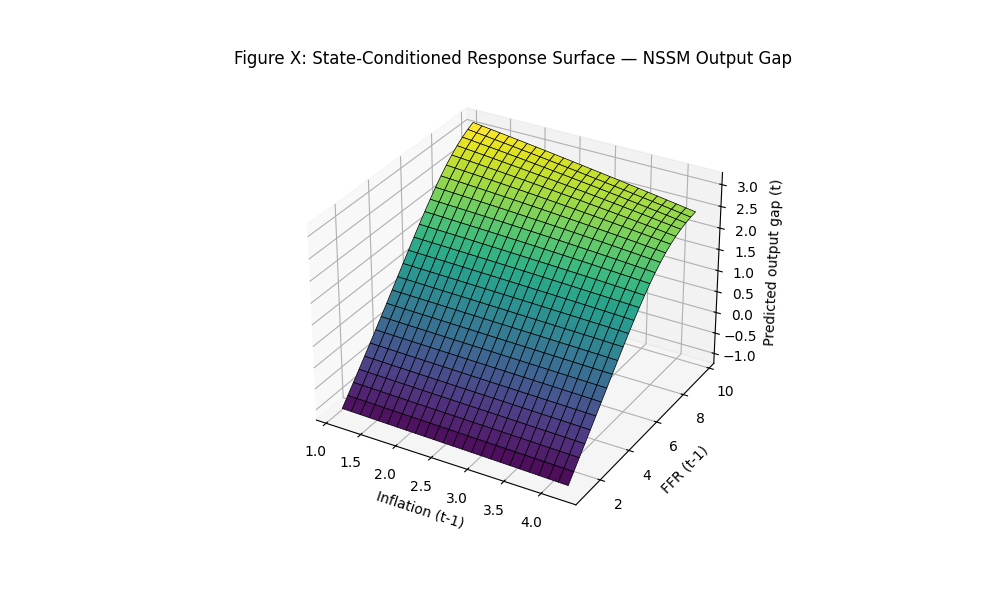

In [ ]:
# State-conditioned output-gap response surface:
# Vary lagged inflation pi_{t-1} and lagged policy rate i_{t-1},
# while holding the remaining output-gap regressors fixed at anchor values.

pi_vals = np.linspace(float(df_train["pi"].min()), float(df_train["pi"].max()), 25)
i_vals = np.linspace(float(df_train["i"].min()), float(df_train["i"].max()), 25)

PI_GRID, I_GRID = np.meshgrid(pi_vals, i_vals)
Z_Y = np.zeros_like(PI_GRID, dtype=float)

nssm.eval()
with torch.no_grad():
    for r in range(PI_GRID.shape[0]):
        for c in range(PI_GRID.shape[1]):
            pi_lag1_val = float(PI_GRID[r, c])
            i_lag1_val = float(I_GRID[r, c])

            # Output-gap regressor order:
            # [y_{t-1}, y_{t-2}, pi_{t-1}, pi_{t-2}, i_{t-1}, i_{t-2}]
            x_y_grid = x_y_anchor.clone()
            x_y_grid[0, 2] = pi_lag1_val
            x_y_grid[0, 4] = i_lag1_val

            # Keep the inflation block frozen at anchor inputs/state.
            _, _, y_t_grid, _ = nssm(
                h_y_anchor,
                h_pi_anchor,
                x_y_grid,
                x_pi_anchor,
            )

            Z_Y[r, c] = float(y_t_grid.item())

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    PI_GRID,
    I_GRID,
    Z_Y,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.5,
    alpha=0.95,
)

ax.set_title("Figure X: State-Conditioned Response Surface — NSSM Output Gap")
ax.set_xlabel("Inflation (t-1)")
ax.set_ylabel("FFR (t-1)")
ax.set_zlabel("Predicted output gap (t)")

plt.show()

figure_nssm_state_conditioned_y = fig

**Note:** This figure conditions on the output-gap block's latent state at the anchor quarter and shows how the fitted NSSM's output-gap prediction varies with lagged inflation and the lagged policy rate, while the remaining regressors are fixed at their anchor-quarter values.

## Out-of-Sample NSSM Fit — One-Step Actual vs Predicted Values

To evaluate the neural state-space model outside the estimation sample, we next generate one-step out-of-sample predictions over the post-2007 period.

Because the NSSM is a recursive latent-state model, the out-of-sample evaluation is constructed by propagating the fitted model forward over the full aligned sequence and then extracting the post-2007 segment. This preserves the latent-state history inherited from the training sample and therefore provides a more coherent out-of-sample assessment than restarting the model only at the beginning of the evaluation window.

As in the earlier NSSM specification, the inflation block uses the full-information regressor set, so this should be interpreted as a one-step conditional out-of-sample evaluation rather than a fully recursive counterfactual simulation.

In [ ]:
# Combine the training and out-of-sample samples into one full quarterly panel.
# This preserves the latent-state history needed by the fitted NSSM.

df_nssm_full = pd.concat([df_train, df_oos], axis=0)
df_nssm_full = df_nssm_full[~df_nssm_full.index.duplicated(keep="first")]
df_nssm_full = df_nssm_full.loc[:, ["pi", "y", "i"]].sort_index()

print(df_nssm_full.head())
print(df_nssm_full.tail())
print("Full NSSM span:", df_nssm_full.index.min(), "→", df_nssm_full.index.max(), "| rows:", len(df_nssm_full))

             pi         y     i
date                           
1987Q3  2.66122 -0.320752  6.84
1987Q4  2.91876  0.612983  6.92
1988Q1  3.06577  0.370773  6.66
1988Q2  3.35274  0.932239  7.16
1988Q3  3.80207  0.779457  7.98
             pi         y     i
date                           
2024Q4  2.46749  1.353586  4.65
2025Q1  2.57530  0.570385  4.33
2025Q2  2.46151  0.944681  4.33
2025Q3  2.97066  1.464017  4.29
2025Q4  3.30091  1.026932  3.90
Full NSSM span: 1987Q3 → 2025Q4 | rows: 154


The full NSSM input sequence is rebuilt over the combined training and out-of-sample panel. This is necessary because the latent state at each quarter depends on the earlier recursive history.

In [ ]:
# Rebuild the full-information NSSM inputs on the combined sample.
# This uses the same full-information input design as the fitted NSSM section.

nssm_inputs_full = build_full_nssm_inputs(
    df=df_nssm_full,
    dtype=DTYPE,
    device=DEVICE,
)

X_y_nssm_full = nssm_inputs_full.X_y
y_target_nssm_full = nssm_inputs_full.y_target
X_pi_nssm_full = nssm_inputs_full.X_pi
pi_target_nssm_full = nssm_inputs_full.pi_target
time_index_nssm_full = nssm_inputs_full.time_index

print("Full NSSM output-gap input shape:", tuple(X_y_nssm_full.shape))
print("Full NSSM inflation input shape:", tuple(X_pi_nssm_full.shape))
print("Full NSSM output-gap target shape:", tuple(y_target_nssm_full.shape))
print("Full NSSM inflation target shape:", tuple(pi_target_nssm_full.shape))
print("Full NSSM lag-aligned span:", time_index_nssm_full[0], "→", time_index_nssm_full[-1])

Full NSSM output-gap input shape: (152, 6)
Full NSSM inflation input shape: (152, 7)
Full NSSM output-gap target shape: (152, 1)
Full NSSM inflation target shape: (152, 1)
Full NSSM lag-aligned span: 1988Q1 → 2025Q4


The combined input sequence is then passed through the retained fitted NSSM. The resulting predicted paths are aligned with the full lag-adjusted sample, after which the out-of-sample segment is extracted.

In [ ]:
# Run the fitted NSSM over the full aligned sequence.
# This preserves the state evolution learned from the training history.

with torch.no_grad():
    y_hat_nssm_full, pi_hat_nssm_full, states_y_nssm_full, states_pi_nssm_full = run_two_block_nssm_sequence(
        model=nssm,
        X_y=X_y_nssm_full,
        X_pi=X_pi_nssm_full,
        h0_y=h0_y_nssm,
        h0_pi=h0_pi_nssm,
    )

print("Full NSSM predicted output-gap shape:", tuple(y_hat_nssm_full.shape))
print("Full NSSM predicted inflation shape:", tuple(pi_hat_nssm_full.shape))
print("Full NSSM state_y shape:", tuple(states_y_nssm_full.shape))
print("Full NSSM state_pi shape:", tuple(states_pi_nssm_full.shape))

Full NSSM predicted output-gap shape: (152, 1)
Full NSSM predicted inflation shape: (152, 1)
Full NSSM state_y shape: (152, 4)
Full NSSM state_pi shape: (152, 4)


In [ ]:
# Build the full fitted-value dataframe, then keep only the post-2007 out-of-sample segment.

fit_nssm_full = pd.DataFrame(
    {
        "y_actual": y_target_nssm_full.detach().cpu().numpy().reshape(-1),
        "y_hat": y_hat_nssm_full.detach().cpu().numpy().reshape(-1),
        "pi_actual": pi_target_nssm_full.detach().cpu().numpy().reshape(-1),
        "pi_hat": pi_hat_nssm_full.detach().cpu().numpy().reshape(-1),
    },
    index=pd.Index(time_index_nssm_full, name="date"),
).sort_index()

fit_nssm_full["resid_y_nssm"] = fit_nssm_full["y_actual"] - fit_nssm_full["y_hat"]
fit_nssm_full["resid_pi_nssm"] = fit_nssm_full["pi_actual"] - fit_nssm_full["pi_hat"]
fit_nssm_full["se_y_nssm"] = fit_nssm_full["resid_y_nssm"] ** 2
fit_nssm_full["se_pi_nssm"] = fit_nssm_full["resid_pi_nssm"] ** 2

fit_nssm_oos_1step = fit_nssm_full.loc["2007Q3":].copy()

print(fit_nssm_oos_1step.head())
print(fit_nssm_oos_1step.tail())
print("One-step NSSM OOS span:", fit_nssm_oos_1step.index.min(), "→", fit_nssm_oos_1step.index.max())

        y_actual     y_hat  pi_actual    pi_hat  resid_y_nssm  resid_pi_nssm  \
date                                                                           
2007Q3  1.213636  0.811529    2.57376  2.737258      0.402107      -0.163498   
2007Q4  1.338861  0.990486    2.62239  2.696884      0.348375      -0.074494   
2008Q1  0.406716  0.774356    2.03211  3.383965     -0.367639      -1.351855   
2008Q2  0.527217 -0.103962    1.81848  1.410943      0.631179       0.407537   
2008Q3 -0.445713  0.032168    2.02788  2.125557     -0.477880      -0.097677   

        se_y_nssm  se_pi_nssm  
date                           
2007Q3   0.161690    0.026732  
2007Q4   0.121365    0.005549  
2008Q1   0.135159    1.827511  
2008Q2   0.398387    0.166087  
2008Q3   0.228370    0.009541  
        y_actual     y_hat  pi_actual    pi_hat  resid_y_nssm  resid_pi_nssm  \
date                                                                           
2024Q4  1.353586  1.298964    2.46749  2.632018      0.

To mirror the earlier ANN and NSSM diagnostics, the one-step out-of-sample predictions are collected in a single aligned dataframe containing realized values, predicted values, residuals, and squared errors.

/var/folders/cj/p5jdwnb923752l7zjc_69j5w0000gn/T/ipykernel_15268/585729750.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 4))


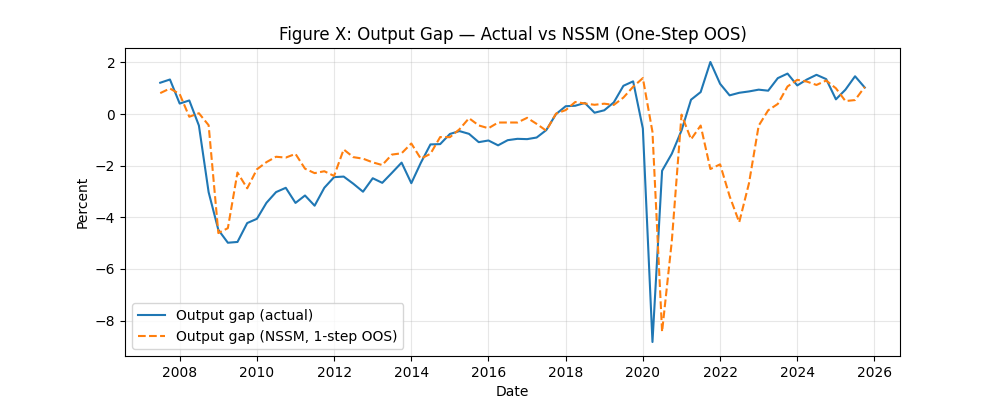

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    fit_nssm_oos_1step.index.to_timestamp(),
    fit_nssm_oos_1step["y_actual"],
    label="Output gap (actual)",
)

ax.plot(
    fit_nssm_oos_1step.index.to_timestamp(),
    fit_nssm_oos_1step["y_hat"],
    "--",
    label="Output gap (NSSM, 1-step OOS)",
)

ax.set_title("Figure X: Output Gap — Actual vs NSSM (One-Step OOS)")
ax.set_xlabel("Date")
ax.set_ylabel("Percent")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

figure_output_gap_nssm_oos_1step = fig

**Note:** This figure shows the realized output gap and the one-step out-of-sample NSSM predictions over the post-2007 evaluation period.

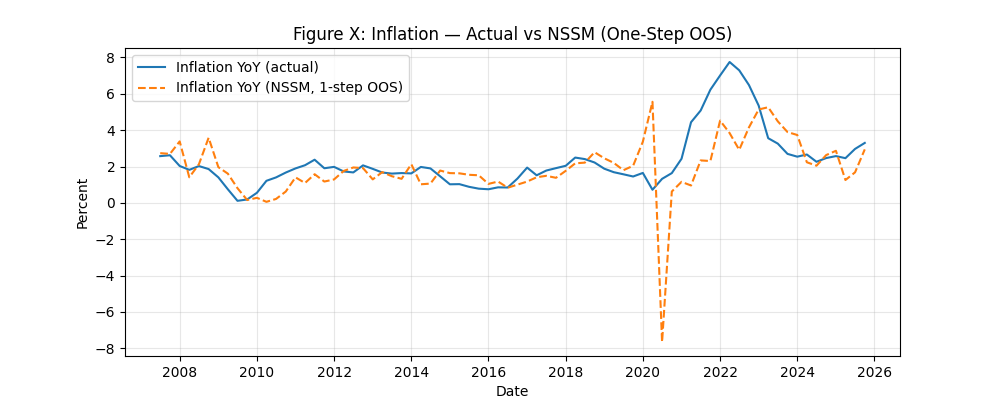

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    fit_nssm_oos_1step.index.to_timestamp(),
    fit_nssm_oos_1step["pi_actual"],
    label="Inflation YoY (actual)",
)

ax.plot(
    fit_nssm_oos_1step.index.to_timestamp(),
    fit_nssm_oos_1step["pi_hat"],
    "--",
    label="Inflation YoY (NSSM, 1-step OOS)",
)

ax.set_title("Figure X: Inflation — Actual vs NSSM (One-Step OOS)")
ax.set_xlabel("Date")
ax.set_ylabel("Percent")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

figure_inflation_nssm_oos_1step = fig

**Note:** This figure shows the realized inflation series and the one-step out-of-sample NSSM predictions over the post-2007 evaluation period.

----------------------

# References (APA)

## Software
1. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (v3.0.0). Zenodo. https://doi.org/10.5281/zenodo.17635942

2. The pandas development team. (2026). pandas-dev/pandas: Pandas (v3.0.1). Zenodo. https://doi.org/10.5281/zenodo.18675244

3. Python Software Foundation. (2025). Python (Version 3.13.7) [Computer software]. Python Software Foundation. https://www.python.org/

4. The Matplotlib Development Team. (2025). Matplotlib: Visualization with Python (v3.10.8). Zenodo. https://doi.org/10.5281/zenodo.17595503

5. Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. Nature, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

6. Thomas, Kluyver & Benjamin, Ragan-Kelley & Fernando, Perez & Brian, Granger & Matthias, Bussonnier & Jonathan, Frederic & Kyle, Kelley & Jessica, Hamrick & Jason, Grout & Sylvain, Corlay & Paul, Ivanov & Damian, Avila & Safia, Abdalla & Carol, Willing & Team, Jupyter. (2016). Jupyter Notebooks – a publishing format for reproducible computational workflows. 10.3233/978-1-61499-649-1-87.

7. Ansel, J., Yang, E., He, H., Gimelshein, N., Jain, A., Voznesensky, M., Bao, B., Bell, P., Berard, D., Burovski, E., Chauhan, G., Chourdia, A., Constable, W., Desmaison, A., DeVito, Z., Ellison, E., Feng, W., Gong, J., Gschwind, M., Hirsh, B., Huang, S., Kalambarkar, K., Kirsch, L., Lazos, M., Lezcano, M., Liang, Y., Liang, J., Lu, Y., Luk, C., Maher, B., Pan, Y., Puhrsch, C., Reso, M., Saroufim, M., Siraichi, M. Y., Suk, H., Suo, M., Tillet, P., Wang, E., Wang, X., Wen, W., Zhang, S., Zhao, X., Zhou, K., Zou, R., Mathews, A., Chanan, G., Wu, P., & Chintala, S. (2024). PyTorch 2: Faster Machine Learning Through Dynamic Python Bytecode Transformation and Graph Compilation [Conference paper]. 29th ACM International Conference on Architectural Support for Programming Languages and Operating Systems, Volume 2 (ASPLOS '24). https://doi.org/10.1145/3620665.3640366

## Papers & Books
1. Chen, S., & Billings, S. A. (1992). Neural networks for nonlinear dynamic system modelling and identification. *International Journal of Control*, 56(2), 319–346. https://doi.org/10.1080/00207179208934317

2. Narendra, K. S., & Parthasarathy, K. (1990). Identification and control of dynamical systems using neural networks. *IEEE transactions on neural networks*, 1(1), 4–27. https://doi.org/10.1109/72.80202

3. Raiko, T., Valpola, H., & LeCun, Y. (2012). Deep Learning Made Easier by Linear Transformations in Perceptrons. *International Conference on Artificial Intelligence and Statistics*.

4. Nguyen, D., & Widrow, B. (1990). Neural Network for Self-Learning Control Systems. *Control Systems Magazine*, IEEE. 10. 18 - 23. https://doi.org/10.1109/37.55119.

5. Levenberg, K. (1944) A Method for the Solution of Certain Non-Linear Problems in Least Squares. *Quarterly of Applied Mathematics*, 2, 164-168. https://doi.org/10.1090/qam/10666

6. Marquardt, D. W. (1963). An Algorithm for Least-Squares Estimation of Nonlinear Parameters. *Journal of the Society for Industrial and Applied Mathematics*, 11(2), 431–441. http://www.jstor.org/stable/2098941

7. Aras, S., & Kocakoç, I. D. (2016). A new model selection strategy in time series forecasting with artificial neural networks. *IHTS. Neurocomputing.* 174. 10.1016/j.neucom.2015.10.036.

8. White, H. (1988). Economic prediction using neural networks: The case of IBM daily stock returns. *Proceedings of the IEEE International Conference on Neural Networks*, 2, 451–458.

9. Swanson, N. R., & White, H. (1997). A model selection approach to assessing the information in the term structure using linear models and artificial neural networks. *Journal of Business & Economic Statistics*, 15(4), 370–386.

10. Durbin, J., & Koopman, S. J. (2001). Time Series Analysis by State Space Methods. https://doi.org/10.1093/acprof:oso/9780199641178.001.0001

11. Fraccaro, M., & Sønderby, S., & Paquet, U., & Winther, O. (2016). Sequential Neural Models with Stochastic Layers. https://doi.org/10.48550/arXiv.1605.07571

12. Krishnan, R. G., Shalit, U., Sontag, D., (2017). Structured Inference Networks for Nonlinear State Space Models. https://doi.org/10.48550/arXiv.1609.09869

13. Rangapuram, S. S., Seeger, M., Gasthaus, J., Stella, L., Yuyang, Wang., Januschowski, T. (2018). Deep State Space Models for Time Series Forecasting. *NIPS'18: Proceedings of the 32nd International Conference on Neural Information Processing Systems*, 7796-7805.

14. Elfwing, S., & Uchibe, Eiji & Doya, Kenji. (2018). Unbounded Output Networks for Classification. https://doi.org/10.48550/arXiv.1807.09443

15. Ramachandran, P., Zoph, B., & Le, Q.V. (2018). Searching for Activation Functions. *ArXiv*, https://doi.org/abs/1710.05941

16. Saxe, A., & Mcclelland, J., & Ganguli, S. (2013). Exact solutions to the nonlinear dynamics of learning in deep linear neural networks. https://doi.org/10.48550/arXiv.1312.6120

17. Hu, W., Xiao, L., & Pennington, J. (2020). Provable Benefit of Orthogonal Initialization in Optimizing Deep Linear Networks. *ArXiv*, https://doi.org/abs/2001.05992

18. Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. *International Conference on Artificial Intelligence and Statistics*.

19. Loshchilov, I., & Hutter, F. (2017). Decoupled Weight Decay Regularization. *International Conference on Learning Representations*. https://doi.org/10.48550/arXiv.1711.05101


